In [1]:
# ============================================================
# CELL 1.1 — Environment Verification
#
# Installation is handled OUTSIDE the notebook via:
#   uv sync --extra parsers        (fast parsers only)
#   uv sync --all-extras           (full benchmark)
#
# This cell verifies you're running inside the uv-managed venv
# and that the core dependencies are importable. If something
# is missing, it tells you the exact uv sync command to fix it.
# ============================================================

import sys
import gc
from pathlib import Path

# ---- 1. Confirm we're inside the uv venv, not system Python ----
venv_path = Path(sys.prefix)
in_venv = venv_path.name == ".venv" or (venv_path / "pyvenv.cfg").exists()

if not in_venv:
    print(
        "⚠ WARNING: You don't appear to be running inside the uv venv.\n"
        "  Launch the notebook with:\n"
        "    uv run jupyter notebook notebooks/benchmark.ipynb\n"
        "  This ensures the correct interpreter and all installed packages are used."
    )
else:
    print(f"✓ Running inside venv: {venv_path}")

print(f"  Python {sys.version}")
print(f"  Executable: {sys.executable}\n")

# ---- 2. Verify core dependencies ----
# These are in [project.dependencies] — always present after any uv sync.
CORE_DEPS = [
    ("numpy", "numpy"),
    ("pandas", "pandas"),
    ("matplotlib", "matplotlib"),
    ("seaborn", "seaborn"),
    ("sklearn", "scikit-learn"),
    ("sentence_transformers", "sentence-transformers"),
    ("qdrant_client", "qdrant-client"),
    ("rouge_score", "rouge-score"),
    ("tqdm", "tqdm"),
    ("rich", "rich"),
    ("dotenv", "python-dotenv"),
    ("chonkie", "chonkie[semantic]"),
    ("langchain_text_splitters", "langchain-text-splitters"),
]

missing_core = []
for import_name, pip_name in CORE_DEPS:
    try:
        __import__(import_name)
        print(f"  ✓ {pip_name}")
    except ImportError:
        print(f"  ✗ {pip_name}  ← MISSING")
        missing_core.append(pip_name)

if missing_core:
    print(
        f"\n✗ {len(missing_core)} core dependencies missing. Run:\n"
        "    uv sync\n"
        "  then restart the kernel."
    )
else:
    print("\n✓ All core dependencies present.")

# ---- 3. Check optional parser groups ----
OPTIONAL_DEPS = {
    "parsers": [
        ("fitz", "pymupdf"),
        ("pdfplumber", "pdfplumber"),
        ("openparse", "openparse"),
    ],
    "heavy": [
        ("docling", "docling[pdf]"),
        ("marker", "marker-pdf"),
        ("unstructured", "unstructured[pdf]"),
    ],
    "cloud": [
        ("llama_parse", "llama-parse"),
    ],
}

print("\n── Optional parser groups ──")
for group, deps in OPTIONAL_DEPS.items():
    available = []
    missing = []
    for import_name, pip_name in deps:
        try:
            __import__(import_name)
            available.append(pip_name)
        except ImportError:
            missing.append(pip_name)

    status = "✓" if not missing else "partial" if available else "✗"
    print(f"  [{status}] --extra {group}")
    for name in available:
        print(f"        ✓ {name}")
    for name in missing:
        print(f"        ✗ {name}  ← uv sync --extra {group}")

✓ Running inside venv: /home/dali/pdf-parser-benchmark/.venv
  Python 3.12.3 (main, Mar  3 2026, 12:15:18) [GCC 13.3.0]
  Executable: /home/dali/pdf-parser-benchmark/.venv/bin/python

  ✓ numpy
  ✓ pandas
  ✓ matplotlib
  ✓ seaborn
  ✓ scikit-learn
  ✓ sentence-transformers
  ✓ qdrant-client
  ✓ rouge-score
  ✓ tqdm
  ✓ rich
  ✓ python-dotenv
  ✓ chonkie[semantic]
  ✓ langchain-text-splitters

✓ All core dependencies present.

── Optional parser groups ──
  [✓] --extra parsers
        ✓ pymupdf
        ✓ pdfplumber
        ✓ openparse
  [✓] --extra heavy
        ✓ docling[pdf]
        ✓ marker-pdf
        ✓ unstructured[pdf]
  [✗] --extra cloud
        ✗ llama-parse  ← uv sync --extra cloud


In [2]:
# Non-parser imports — always required
import subprocess
from typing import Optional
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from enum import Enum
import seaborn as sns
from tqdm import tqdm
from rich.console import Console
from dotenv import load_dotenv
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams, PointStruct
from sentence_transformers import SentenceTransformer
from rouge_score import rouge_scorer
from chonkie import SemanticChunker
from langchain_text_splitters import RecursiveCharacterTextSplitter

load_dotenv()
console = Console()

# Parser availability — read by BaseParser.is_available()
# Actual import happens inside each parser's _extract() method
# so a missing parser never breaks the notebook on import
PARSER_AVAILABLE: dict[str, bool] = {}

for parser_name, import_name in [
    ("pymupdf", "fitz"),
    ("pdfplumber", "pdfplumber"),
    ("docling", "docling"),
    ("unstructured", "unstructured"),
    ("openparse", "openparse"),
    ("llamaparse", "llama_parse"),
]:
    try:
        __import__(import_name)
        PARSER_AVAILABLE[parser_name] = True
    except ImportError:
        PARSER_AVAILABLE[parser_name] = False

# LiteParse — Node.js availability check
try:
    __import__("liteparse")
    PARSER_AVAILABLE["liteparse"] = True
except ImportError:
    PARSER_AVAILABLE["liteparse"] = False

console.print(PARSER_AVAILABLE)

{
    'pymupdf': True,
    'pdfplumber': True,
    'docling': True,
    'unstructured': True,
    'openparse': True,
    'llamaparse': False,
    'liteparse': True
}

In [3]:
from dataclasses import dataclass, field, asdict

# ---- Global config ----
PDF_PATH = Path("/home/dali/pdf-parser-benchmark/data/Jeanne Boyarsky, Scott Selikoff - OCP Oracle Certified Professional Java SE 17 Developer Study Guide - Exam 1Z0-829.-Sybex (2022).pdf")
CACHE_DIR = Path("./benchmark_cache")
RESULTS_DIR = Path("./benchmark_results")
EMBEDDING_MODEL_NAME = "BAAI/bge-small-en-v1.5"
EMBEDDING_DIM = 384
QDRANT_COLLECTION_PREFIX = "benchmark_"
SEMANTIC_CHUNK_SIZE = 1024
RECURSIVE_CHUNK_SIZE = 1000
RECURSIVE_CHUNK_OVERLAP = 150

CACHE_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

# ---- Result types ----

@dataclass
class ExtractionResult:
    """
    Output of running one parser on the full PDF.
    
    raw_text: Concatenated full text, newline-separated by page.
              Used for chunking and chunk quality evaluation.
    pages:    Per-page text list. Index 0 = page 1.
              Needed to compute page-level code block density.
    metadata: Parser-specific structured output (e.g., Docling's
              DoclingDocument, openparse's Node list). Stored as
              a list of dicts for uniform downstream handling.
    extraction_time_s: Wall-clock seconds for the full parse.
    parser_name: Matches the key in PARSER_AVAILABLE.
    error: Non-None if the parser raised during extraction.
           We store it rather than re-raising so the loop continues.
    """
    parser_name: str
    raw_text: str = ""
    pages: list[str] = field(default_factory=list)
    metadata: list[dict] = field(default_factory=list)
    extraction_time_s: float = 0.0
    error: Optional[str] = None

@dataclass
class Chunk:
    """
    A single chunk produced by one (parser, chunker) combination.
    
    chunk_id:    Stable identifier: "{parser}_{chunker}_{index:04d}"
    text:        The chunk text.
    parser:      Which parser produced the source text.
    chunker:     "semantic" | "recursive"
    char_count / token_count: Raw size metrics.
    starts_mid_sentence: Heuristic — does the chunk start with a
                         lowercase letter? Indicates a bad split.
    ends_mid_sentence:   Does the chunk end without terminal punctuation?
    contains_code_block: Heuristic — does the chunk contain a Java
                         code pattern (braces, semicolons, keywords)?
    code_block_fragmented: True if the chunk contains an *unclosed*
                           code block (opening brace without closing).
    """
    chunk_id: str
    text: str
    parser: str
    chunker: str
    char_count: int = 0
    token_count: int = 0
    starts_mid_sentence: bool = False
    ends_mid_sentence: bool = False
    contains_code_block: bool = False
    code_block_fragmented: bool = False

@dataclass
class ChunkQualityReport:
    """
    Aggregate quality metrics for one (parser, chunker) pair.
    
    total_chunks:           How many chunks were produced.
    avg_chunk_size_chars:   Mean chunk length in characters.
    code_block_preservation_rate: Fraction of detected code blocks
                             that are intact (not fragmented).
    mid_sentence_start_rate: Fraction of chunks starting mid-sentence.
    mid_sentence_end_rate:   Fraction of chunks ending mid-sentence.
    avg_rouge_l:             Mean ROUGE-L vs. gold reference passages
                             (computed in Cell 4).
    """
    parser: str
    chunker: str
    total_chunks: int = 0
    avg_chunk_size_chars: float = 0.0
    code_block_preservation_rate: float = 0.0
    mid_sentence_start_rate: float = 0.0
    mid_sentence_end_rate: float = 0.0
    avg_rouge_l: float = 0.0
    avg_bleu: float = 0.0
    avg_semantic_sim: float = 0.0

@dataclass
class RetrievalResult:
    """
    Retrieval evaluation for one (parser, chunker) pair on one query.
    
    query_id:          Index into the gold query set.
    query_text:        The query string.
    retrieved_chunk_ids: Top-K chunk IDs returned by Qdrant.
    relevant_chunk_ids:  Gold-annotated relevant chunk IDs for this query.
    precision_at_k:    |retrieved ∩ relevant| / k
    recall_at_k:       |retrieved ∩ relevant| / |relevant|
    """
    parser: str
    chunker: str
    query_id: int
    query_text: str
    retrieved_chunk_ids: list[str] = field(default_factory=list)
    relevant_chunk_ids: list[str] = field(default_factory=list)
    precision_at_k: float = 0.0
    recall_at_k: float = 0.0

# ---- LiteParse Node.js runner scaffold ----


# ---- Sanity check: PDF exists ----
if not PDF_PATH.exists():
    console.print(
        f"[bold red]⚠ PDF not found at '{PDF_PATH}'. "
        "Update PDF_PATH before running the extraction cells.[/bold red]"
    )
else:
    size_mb = PDF_PATH.stat().st_size / 1_048_576
    console.print(f"[green]✓ PDF found:[/green] {PDF_PATH.name} ({size_mb:.1f} MB)")

console.print("\n[bold]Configuration[/bold]")
console.print(f"  Embedding model : {EMBEDDING_MODEL_NAME}")
console.print(f"  Semantic chunk size : {SEMANTIC_CHUNK_SIZE} tokens")
console.print(f"  Recursive chunk size: {RECURSIVE_CHUNK_SIZE} chars (overlap: {RECURSIVE_CHUNK_OVERLAP})")
console.print(f"  Cache dir  : {CACHE_DIR}")
console.print(f"  Results dir: {RESULTS_DIR}")

✓ PDF found: Jeanne Boyarsky, Scott Selikoff - OCP Oracle Certified Professional Java SE 17 Developer Study Guide -
Exam 1Z0-829.-Sybex (2022).pdf (19.1 MB)

Configuration

Embedding model : BAAI/bge-small-en-v1.5

Semantic chunk size : 1024 tokens

Recursive chunk size: 1000 chars (overlap: 150)

Cache dir  : benchmark_cache

Results dir: benchmark_results

In [4]:
import hashlib
import json
from abc import ABC, abstractmethod

class BaseParser(ABC):
    """
    Abstract base class for all PDF parsers in this benchmark.
    
    Subclasses implement _extract() with their parser-specific logic.
    The public extract() method wraps _extract() with:
      - Cache check (load from disk if already parsed)
      - Wall-clock timing
      - Error isolation (exceptions stored in result.error, not raised)
    """

    def __init__(self, cache_dir: Path = CACHE_DIR):
        self.cache_dir = cache_dir
        self.name = self.__class__.__name__.replace("Parser", "").lower()

    def _pdf_hash(self, pdf_path: Path) -> str:
        """
        SHA-256 of the first 64KB of the PDF.
        
        We don't hash the entire file (could be hundreds of MB) — the
        first 64KB is enough to detect if the file changed between runs.
        Collisions here would just mean a stale cache hit, not a
        correctness issue.
        """
        h = hashlib.sha256()
        with open(pdf_path, "rb") as f:
            h.update(f.read(65536))
        return h.hexdigest()[:16]  # 16 hex chars is plenty for a cache key

    def _cache_path(self, pdf_path: Path) -> Path:
        pdf_hash = self._pdf_hash(pdf_path)
        return self.cache_dir / f"{self.name}_{pdf_hash}.json"

    def _load_cache(self, pdf_path: Path) -> Optional[ExtractionResult]:
        cache_path = self._cache_path(pdf_path)
        if not cache_path.exists():
            return None
        try:
            with open(cache_path) as f:
                data = json.load(f)
            result = ExtractionResult(**data)
            # Don't replay failures — always retry failed parsers
            if result.error:
                console.print(f"  [yellow]Previous run failed for {self.name} — retrying[/yellow]")
                return None
            console.print(f"  [dim]Cache hit for {self.name} — loading from {cache_path.name}[/dim]")
            return result
        except Exception as e:
            console.print(f"  [yellow]Cache read failed for {self.name}: {e} — re-extracting[/yellow]")
            return None

    def _save_cache(self, result: ExtractionResult, pdf_path: Path) -> None:
        cache_path = self._cache_path(pdf_path)
        try:
            def default_serializer(obj):
                if isinstance(obj, set):
                    return list(obj)
                if isinstance(obj, Enum):
                    return obj.value
                raise TypeError(f"Object of type {type(obj)} is not JSON serializable")
    
            with open(cache_path, "w") as f:
                json.dump(asdict(result), f, ensure_ascii=False, default=default_serializer)
        except Exception as e:
            console.print(f"  [yellow]Cache write failed for {self.name}: {e}[/yellow]")

    def extract(self, pdf_path: Path) -> ExtractionResult:
        """
        Public entry point. Handles caching, timing, and error isolation.
        Subclasses implement _extract() instead of overriding this.
        """
        # Cache check
        cached = self._load_cache(pdf_path)
        if cached is not None:
            return cached

        console.print(f"\n[bold cyan]→ Running {self.name}...[/bold cyan]")
        start = time.perf_counter()

        try:
            result = self._extract(pdf_path)
            result.extraction_time_s = time.perf_counter() - start
            result.parser_name = self.name
        except Exception as e:
            result = ExtractionResult(
                parser_name=self.name,
                extraction_time_s=time.perf_counter() - start,
                error=f"{type(e).__name__}: {e}",
            )
            console.print(f"  [red]✗ {self.name} failed: {result.error}[/red]")

        self._save_cache(result, pdf_path)
        return result

    @abstractmethod
    def _extract(self, pdf_path: Path) -> ExtractionResult:
        """
        Parser-specific extraction logic.
        Must return an ExtractionResult with at minimum raw_text populated.
        extraction_time_s and parser_name are set by the base class.
        """
        ...

    def is_available(self) -> bool:
        """
        Returns True if this parser's dependencies are installed.
        Checked before running — unavailable parsers are skipped cleanly.
        """
        return PARSER_AVAILABLE.get(self.name, False)

In [5]:
import pdfplumber

class PDFPlumberParser(BaseParser):

    def _extract(self, pdf_path: Path) -> ExtractionResult:

        pages = []
        metadata_tables = []

        with pdfplumber.open(str(pdf_path)) as pdf:
            for page_num, page in enumerate(tqdm(pdf.pages, desc="pdfplumber pages")):

                # Extract tables first
                tables = page.extract_tables()
                table_texts = []
                table_bboxes = []

                for table in (tables or []):
                    if not table:
                        continue
                    rows = []
                    for row in table:
                        cells = [str(cell or "").strip() for cell in row]
                        rows.append("| " + " | ".join(cells) + " |")
                    table_text = "\n".join(rows)
                    table_texts.append(table_text)
                    metadata_tables.append({
                        "page": page_num,
                        "rows": len(table),
                        "cols": len(table[0]) if table else 0,
                        "text": table_text,
                    })

                # Crop out table bounding boxes before extracting prose
                # to avoid duplicate content
                cropped_page = page
                for table_obj in page.find_tables():
                    cropped_page = cropped_page.outside_bbox(table_obj.bbox)

                page_text = cropped_page.extract_text(
                    x_tolerance=3,
                    y_tolerance=3,
                ) or ""

                # Combine prose + tables
                full_page = page_text
                if table_texts:
                    full_page += "\n\n" + "\n\n".join(table_texts)

                pages.append(full_page)

        raw_text = "\n".join(pages)

        return ExtractionResult(
            parser_name=self.name,
            raw_text=raw_text,
            pages=pages,
            metadata=metadata_tables,
        )

In [6]:
import pymupdf

class PyMuPDFParser(BaseParser):

    def _extract(self, pdf_path: Path) -> ExtractionResult:
          # PyMuPDF

        doc = pymupdf.open(str(pdf_path))
        pages = []
        metadata_blocks = []

        for page_num, page in enumerate(tqdm(doc, desc="PyMuPDF pages")):
            # "text" mode: respects reading order, joins words into lines
            page_text = page.get_text("text")
            pages.append(page_text)

            # "blocks" mode: returns (x0, y0, x1, y1, text, block_no, block_type)
            # block_type 0 = text, 1 = image
            # We store block-level data for the code block analysis in Cell 4.
            blocks = page.get_text("blocks")
            for block in blocks:
                if block[6] == 0:  # text block only
                    metadata_blocks.append({
                        "page": page_num,
                        "bbox": block[:4],
                        "text": block[4],
                        # Font info requires iterating spans — we do a lighter
                        # heuristic here: check if text contains Java code patterns
                        "looks_like_code": _heuristic_is_code(block[4]),
                    })

        doc.close()
        raw_text = "\n".join(pages)

        return ExtractionResult(
            parser_name=self.name,
            raw_text=raw_text,
            pages=pages,
            metadata=metadata_blocks,
        )


def _heuristic_is_code(text: str) -> bool:
    """
    Lightweight heuristic to detect Java code blocks in extracted text.
    
    We look for a combination of signals rather than any single one,
    because each signal alone produces too many false positives:
    - Semicolons at line endings → Java statements
    - Curly braces → Java blocks
    - Java keywords at line start → method/class declarations
    - High punctuation density → code vs prose ratio
    
    This heuristic is used across ALL parsers for a fair comparison.
    A parser that preserves code blocks well will have these signals
    concentrated in dedicated chunks rather than mixed with prose.
    """
    if not text or len(text.strip()) < 20:
        return False

    lines = text.strip().splitlines()
    if not lines:
        return False

    # Signal 1: semicolons ending lines (Java statements)
    semicolon_lines = sum(1 for l in lines if l.rstrip().endswith(";"))

    # Signal 2: curly brace lines
    brace_lines = sum(1 for l in lines if "{" in l or "}" in l)

    # Signal 3: Java keywords at start of (stripped) line
    java_keywords = {
        "public", "private", "protected", "class", "interface",
        "void", "int", "String", "boolean", "return", "import",
        "for", "while", "if", "else", "try", "catch", "new",
        "static", "final", "extends", "implements",
    }
    keyword_lines = sum(
        1 for l in lines
        if l.strip().split(" ")[0] in java_keywords
    )

    total_lines = max(len(lines), 1)
    code_signal = (semicolon_lines + brace_lines + keyword_lines) / total_lines

    # Threshold: >30% of lines showing code signals → treat as code
    return code_signal > 0.3

In [7]:
from docling.document_converter import DocumentConverter, PdfFormatOption
from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import PdfPipelineOptions
import torch

from docling.utils.model_downloader import download_models
from pathlib import Path



class DoclingParser(BaseParser):

    def _extract(self, pdf_path: Path) -> ExtractionResult:
        
        download_models(
    output_dir=Path.home() / ".cache/docling/models",
    with_layout=True,
    with_tableformer=True,
    with_easyocr=False,        # we don't need OCR
    with_code_formula=False,
    with_picture_classifier=False,
)

        # PdfPipelineOptions controls which sub-models run.
        # do_table_structure=True: enables table cell reconstruction
        # do_ocr=False: we have a text-layer PDF, OCR would slow things down
        pipeline_options = PdfPipelineOptions(
            do_table_structure=True,
            do_ocr=False,
        )

        converter = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(
            pipeline_options=pipeline_options
        )
    }
)

        console.print("  [dim]Running Docling conversion (this will take a while)...[/dim]")
        result_doc = converter.convert(str(pdf_path))

        # Export to Markdown — this is the format we use for chunking.
        # Docling's Markdown export uses:
        #   - ## for section headings (detected by font size/style)
        #   - ``` fences for code blocks (detected by layout model)
        #   - | pipes for tables
        markdown_text = result_doc.document.export_to_markdown()

        # Also store the structured element list for Cell 4 analysis.
        # Each element has a label (TEXT, SECTION_HEADER, TABLE, CODE, etc.)
        metadata_elements = []
        for element, _ in result_doc.document.iterate_items():
            metadata_elements.append({
                "label": str(element.label) if hasattr(element, "label") else "unknown",
                "text": element.text if hasattr(element, "text") else "",
            })


        try:
            del converter, result_doc
            _ = gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
                console.print("  [dim]CUDA cache cleared[/dim]")
        except ImportError:
            pass

        # Docling doesn't give us easy per-page text splits,
        # so we use the full markdown as a single "page" entry.
        # Cell 4 will work from raw_text directly for Docling.
        return ExtractionResult(
            parser_name=self.name,
            raw_text=markdown_text,
            pages=[markdown_text],
            metadata=metadata_elements,
        )

In [8]:
from unstructured.partition.pdf import partition_pdf

class UnstructuredParser(BaseParser):

    def _extract(self, pdf_path: Path) -> ExtractionResult:
        

        elements = partition_pdf(
            filename=str(pdf_path),
            strategy="fast",
            include_page_breaks=True,
        )

        pages = []
        metadata_elements = []

        # Elements we want to EXCLUDE from raw_text.
        # Headers and footers in this textbook are page numbers and
        # chapter titles repeated on every page — pure noise for RAG.

        for element in elements:
            category = element.category if hasattr(element, "category") else "Unknown"

            if category == "PageBreak":
                continue  # skip, we use metadata.page_number instead
            
            page_num = getattr(element.metadata, "page_number", 0) or 0

            metadata_elements.append({
                "category": category,
                "text": str(element),
                "page": page_num,
            })

            if category not in {"Header", "Footer"}:
                # Grow pages list dynamically using actual page numbers
                while len(pages) < page_num:
                    pages.append("")
                if page_num > 0:
                    pages[page_num - 1] += "\n" + str(element)

        raw_text = "\n".join(pages)

        return ExtractionResult(
            parser_name=self.name,
            raw_text=raw_text,
            pages=pages,
            metadata=metadata_elements,
        )

In [9]:
import openparse

class OpenParseParser(BaseParser):

    def _extract(self, pdf_path: Path) -> ExtractionResult:
        

        parser = openparse.DocumentParser(
            table_args={
                "parsing_algorithm": "pymupdf",
            }
        )

        console.print("  [dim]Running openparse structural analysis...[/dim]")
        parsed_doc = parser.parse(str(pdf_path))

        pages = []
        metadata_nodes = []
        all_texts = []

        for node in tqdm(parsed_doc.nodes, desc="openparse nodes"):
            node_text = node.text if hasattr(node, "text") else str(node)
            all_texts.append(node_text)

            metadata_nodes.append(json.loads(node.model_dump_json()))

        # openparse doesn't give us page-level splits directly.
        # We use the full text as a single entry and rely on
        # node-level metadata for page attribution in Cell 4.
        raw_text = "\n\n".join(all_texts)
        pages = [raw_text]

        return ExtractionResult(
            parser_name=self.name,
            raw_text=raw_text,
            pages=pages,
            metadata=metadata_nodes,
        )

In [10]:
from liteparse import LiteParse

class LiteParseParser(BaseParser):

    def _extract(self, pdf_path: Path) -> ExtractionResult:

        console.print("  [dim]Running LiteParse spatial extraction...[/dim]")

        parser = LiteParse()
        result = parser.parse(str(pdf_path))

        # LiteParse returns spatial text — layout preserved via
        # indentation and whitespace, not Markdown fencing.
        # result.text is the full document text.
        # result.pages is a list of per-page results with
        # bounding box data per text item.
        full_text = result.text

        pages = [page.text for page in result.pages] if hasattr(result, "pages") else [full_text]

        metadata_entries = []
        if hasattr(result, "pages"):
            for i, page in enumerate(result.pages):
                metadata_entries.append({
                    "page": i,
                    "item_count": len(page.items) if hasattr(page, "items") else 0,
                })

        return ExtractionResult(
            parser_name=self.name,
            raw_text=full_text,
            pages=pages,
            metadata=metadata_entries,
        )

In [11]:
ALL_PARSERS: list[BaseParser] = [
    PyMuPDFParser(),
    PDFPlumberParser(),
    OpenParseParser(),
    UnstructuredParser(),
    DoclingParser(),
    LiteParseParser(),
]

# Filter to only parsers whose dependencies are installed
AVAILABLE_PARSERS = [p for p in ALL_PARSERS if p.is_available()]

console.print(f"\n[bold]Parser registry[/bold]")
for p in ALL_PARSERS:
    status = "[green]✓[/green]" if p.is_available() else "[red]✗ not available[/red]"
    console.print(f"  {status} {p.name}")

console.print(f"\n[bold]{len(AVAILABLE_PARSERS)}/{len(ALL_PARSERS)} parsers ready[/bold]")

Parser registry

✓ pymupdf

✓ pdfplumber

✓ openparse

✓ unstructured

✓ docling

✓ liteparse

6/6 parsers ready

In [12]:
import gc
import psutil

extraction_results: dict[str, ExtractionResult] = {}
GPU_PARSERS = {"docling"}

CPU_PARSERS_LIST = [p for p in AVAILABLE_PARSERS if p.name not in GPU_PARSERS]

ram = psutil.virtual_memory()
console.print(f"Available RAM: {ram.available / 1e9:.1f}GB / {ram.total / 1e9:.1f}GB\n")
console.print(f"[bold]Running CPU parsers on:[/bold] {PDF_PATH.name}\n")

assert PDF_PATH.exists(), f"PDF not found: {PDF_PATH}"

for parser in CPU_PARSERS_LIST:
    console.rule(f"[cyan]{parser.name}[/cyan]")
    result = parser.extract(PDF_PATH)
    extraction_results[parser.name] = result

    if result.error:
        console.print(f"  [red]✗ Failed: {result.error}[/red]")
    else:
        console.print(f"  [green]✓ Done[/green] — "
                      f"{len(result.pages)} pages, "
                      f"{len(result.raw_text):,} chars, "
                      f"{result.extraction_time_s:.1f}s")

# Free RAM before GPU parsers
gc.collect()
ram = psutil.virtual_memory()
console.print(f"\n[bold green]CPU parsers complete.[/bold green]")
console.print(f"Available RAM after cleanup: {ram.available / 1e9:.1f}GB / {ram.total / 1e9:.1f}GB")
console.print("Close any heavy applications before running Cell 3.2.")

Available RAM: 8.0GB / 16.6GB

Running CPU parsers on: Jeanne Boyarsky, Scott Selikoff - OCP Oracle Certified Professional Java SE 17 Developer 
Study Guide - Exam 1Z0-829.-Sybex (2022).pdf

───────────────────────────────────────────────────── pymupdf ─────────────────────────────────────────────────────

Cache hit for pymupdf — loading from pymupdf_d8a2f26d8e91af88.json

✓ Done — 1059 pages, 1,966,343 chars, 4.2s

...

Cache hit for liteparse — loading from liteparse_d8a2f26d8e91af88.json

✓ Done — 1059 pages, 2,148,888 chars, 111.1s

CPU parsers complete.

Available RAM after cleanup: 7.9GB / 16.6GB

Close any heavy applications before running Cell 3.2.

In [13]:
import gc
import psutil

GPU_PARSERS_LIST = [p for p in AVAILABLE_PARSERS if p.name in GPU_PARSERS]

ram = psutil.virtual_memory()
console.print(f"Available RAM: {ram.available / 1e9:.1f}GB / {ram.total / 1e9:.1f}GB\n")

if ram.available / 1e9 < 8:
    console.print(
        "[bold red]⚠ Less than 8GB RAM available. "
        "Risk of OOM crash. Close other applications before proceeding.[/bold red]"
    )

console.print(f"[bold]Running GPU parsers on:[/bold] {PDF_PATH.name}\n")

for parser in GPU_PARSERS_LIST:
    console.rule(f"[cyan]{parser.name}[/cyan]")
    result = parser.extract(PDF_PATH)
    extraction_results[parser.name] = result

    if result.error:
        console.print(f"  [red]✗ Failed: {result.error}[/red]")
    else:
        console.print(f"  [green]✓ Done[/green] — "
                      f"{len(result.pages)} pages, "
                      f"{len(result.raw_text):,} chars, "
                      f"{result.extraction_time_s:.1f}s")

    # Free VRAM + RAM after each GPU parser
    try:
        import torch
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.synchronize()
            console.print(f"  [dim]VRAM cleared after {parser.name}[/dim]")
    except ImportError:
        pass
    gc.collect()
    ram = psutil.virtual_memory()
    console.print(f"  [dim]RAM after {parser.name}: {ram.available / 1e9:.1f}GB available[/dim]")

console.print("\n[bold green]GPU parsers complete.[/bold green]")

Available RAM: 7.9GB / 16.6GB

⚠ Less than 8GB RAM available. Risk of OOM crash. Close other applications before proceeding.

Running GPU parsers on: Jeanne Boyarsky, Scott Selikoff - OCP Oracle Certified Professional Java SE 17 Developer 
Study Guide - Exam 1Z0-829.-Sybex (2022).pdf

───────────────────────────────────────────────────── docling ─────────────────────────────────────────────────────

Cache hit for docling — loading from docling_d8a2f26d8e91af88.json

✓ Done — 1 pages, 2,233,974 chars, 568.8s

VRAM cleared after docling

RAM after docling: 7.8GB available

GPU parsers complete.

In [14]:
# ============================================================
# CELL 4.1 — Chunking Pipeline
#
# Runs all 6 parsers × 2 chunkers = 12 combinations.
# Produces all_chunks: dict keyed by (parser_name, chunker_name)
# → list[Chunk]
#
# Special handling:
# - Docling + openparse return a single large string.
#   We pre-split on Markdown headings before SemanticChunker
#   to avoid embedding thousands of sentences in one shot.
# - SemanticChunker is initialized once and reused.
# - RecursiveCharacterTextSplitter is stateless, no init cost.
# ============================================================

import re
import gc
from dataclasses import asdict

# ---- Initialize chunkers (once) ----

console.print("[bold]Initializing chunkers...[/bold]")


from chonkie import MarkdownChef

MARKDOWN_PARSERS = {"docling"}  # parsers that output Markdown
markdown_chef = MarkdownChef()

def chunk_markdown_parser(parser_name: str, raw_text: str) -> list[str]:
    """
    For Markdown-output parsers: use MarkdownChef to extract
    code blocks and tables as discrete chunks, then apply
    SemanticChunker only on prose text.
    """
    # Write to a temp file since MarkdownChef takes a file path
    import tempfile
    with tempfile.NamedTemporaryFile(
        mode="w", suffix=".md", delete=False, encoding="utf-8"
    ) as f:
        f.write(raw_text)
        tmp_path = f.name

    doc = markdown_chef.process(tmp_path)
    Path(tmp_path).unlink()  # clean up

    chunk_texts = []

    # Code blocks → each is its own chunk, no further splitting
    for code in doc.code:
        if code.content.strip():
            chunk_texts.append(code.content)

    # Tables → each is its own chunk
    for table in doc.tables:
        if table.content.strip():
            chunk_texts.append(table.content)

    # Prose text chunks → run through SemanticChunker in windows
    prose_text = "\n\n".join(c.text for c in doc.chunks if c.text.strip())
    if prose_text:
        windows = presplit_markdown(prose_text)
        for window in tqdm(windows, desc=f"  semantic chunks ({parser_name})"):
            if window.strip():
                semantic_chunks = semantic_chunker.chunk(window)
                chunk_texts.extend([c.text for c in semantic_chunks])

    return chunk_texts

semantic_chunker = SemanticChunker(
    embedding_model=EMBEDDING_MODEL_NAME,
    chunk_size=SEMANTIC_CHUNK_SIZE,        # 1024 tokens
    threshold=0.5,                         # same as CodeMentor production
    min_sentences_per_chunk=1,
    skip_window=1,                         # look past code blocks when merging
)
console.print(f"  ✓ SemanticChunker (model={EMBEDDING_MODEL_NAME}, chunk_size={SEMANTIC_CHUNK_SIZE})")

recursive_splitter = RecursiveCharacterTextSplitter(
    chunk_size=RECURSIVE_CHUNK_SIZE,
    chunk_overlap=RECURSIVE_CHUNK_OVERLAP,
    separators=["\n\n", "\n", ". ", " ", ""],
)
console.print(f"  ✓ RecursiveCharacterTextSplitter (chunk_size={RECURSIVE_CHUNK_SIZE}, overlap={RECURSIVE_CHUNK_OVERLAP})")

# ---- Parsers that return a single large string ----
# These need pre-splitting before SemanticChunker
# to avoid OOM on embedding thousands of sentences at once.
SINGLE_PAGE_PARSERS = {"docling", "openparse"}

def presplit_markdown(text: str, window_size: int = 30000) -> list[str]:
    """
    Split a large Markdown string into windows at heading boundaries.
    Used for Docling and openparse output before SemanticChunker.

    We split on ## and ### headings because:
    - Docling uses these for chapter/section boundaries
    - openparse joins nodes with \n\n, so headings act as anchors
    - 30000 chars ≈ ~7500 tokens, well within SemanticChunker's range
    """
    # Split at any Markdown heading (# ## ###)
    sections = re.split(r'(?=^#{1,3} )', text, flags=re.MULTILINE)

    windows = []
    current = ""
    for section in sections:
        if not section.strip():
            continue
        if len(current) + len(section) > window_size:
            if current.strip():
                windows.append(current)
            current = section
        else:
            current += section
    if current.strip():
        windows.append(current)

    # Fallback: if no headings found, split by paragraph
    if not windows:
        paragraphs = text.split("\n\n")
        current = ""
        for para in paragraphs:
            if len(current) + len(para) > window_size:
                if current.strip():
                    windows.append(current)
                current = para
            else:
                current += "\n\n" + para
        if current.strip():
            windows.append(current)

    return windows


def chunk_with_semantic(parser_name: str, raw_text: str) -> list[str]:
    if parser_name in MARKDOWN_PARSERS:
        return chunk_markdown_parser(parser_name, raw_text)
    
    # All other parsers — window-based semantic chunking
    windows = presplit_markdown(raw_text)
    console.print(f"    [dim]Pre-split into {len(windows)} windows[/dim]")
    chunk_texts = []
    for window in tqdm(windows, desc=f"  semantic chunks ({parser_name})"):
        if window.strip():
            chunks = semantic_chunker.chunk(window)
            chunk_texts.extend([c.text for c in chunks])
    return chunk_texts


def chunk_with_recursive(raw_text: str) -> list[str]:
    """
    Chunk text using RecursiveCharacterTextSplitter.
    Stateless — no special handling needed for large strings.
    """
    return recursive_splitter.split_text(raw_text)


# ---- Run all 12 combinations ----

all_chunks: dict[tuple[str, str], list[Chunk]] = {}

for parser_name, result in extraction_results.items():
    if result.error:
        console.print(f"[yellow]Skipping {parser_name} — extraction failed[/yellow]")
        continue

    console.rule(f"[cyan]{parser_name}[/cyan]")

    for chunker_name in ["semantic", "recursive"]:
        console.print(f"\n  [bold]Chunker: {chunker_name}[/bold]")

        if chunker_name == "semantic":
            chunk_texts = chunk_with_semantic(parser_name, result.raw_text)
        else:
            chunk_texts = chunk_with_recursive(result.raw_text)

        # Build Chunk objects
        chunks = []
        for i, text in enumerate(chunk_texts):
            if not text.strip():
                continue
            chunk = Chunk(
                chunk_id=f"{parser_name}_{chunker_name}_{i:04d}",
                text=text,
                parser=parser_name,
                chunker=chunker_name,
                char_count=len(text),
                token_count=len(text) // 4,  # approximation
            )
            chunks.append(chunk)

        all_chunks[(parser_name, chunker_name)] = chunks
        console.print(f"  ✓ {len(chunks)} chunks produced")

    # Free memory between parsers
    gc.collect()

console.print("\n[bold green]Chunking pipeline complete.[/bold green]")
console.print(f"Total combinations: {len(all_chunks)}")
console.print(f"Total chunks across all combinations: {sum(len(v) for v in all_chunks.values()):,}")

Initializing chunkers...

/home/dali/pdf-parser-benchmark/.venv/lib/python3.12/site-packages/chonkie/embeddings/sentence_transformer.py:62: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  self._dimension = self.model.get_sentence_embedding_dimension()


✓ SemanticChunker (model=BAAI/bge-small-en-v1.5, chunk_size=1024)

✓ RecursiveCharacterTextSplitter (chunk_size=1000, overlap=150)

───────────────────────────────────────────────────── pymupdf ─────────────────────────────────────────────────────

...

Chunker: recursive

✓ 3005 chunks produced

Chunking pipeline complete.

Total combinations: 12

Total chunks across all combinations: 36,497

In [15]:
# ============================================================
# CELL 4.2 — Per-Chunk Quality Annotation
#
# Annotates each chunk with quality signals:
#   - starts_mid_sentence
#   - ends_mid_sentence
#   - contains_code_block
#   - code_block_fragmented
#
# These are heuristics — not perfect, but consistent across
# all parsers which is what matters for comparison.
# ============================================================

def annotate_chunk(chunk: Chunk) -> Chunk:
    """
    Annotates a chunk in-place with quality signals.
    Returns the same chunk for chaining.
    """
    text = chunk.text.strip()

    if not text:
        return chunk

    # ---- Boundary quality ----

    # starts_mid_sentence: first char is lowercase
    # Excludes code blocks (which legitimately start with lowercase)
    first_char = text[0]
    chunk.starts_mid_sentence = (
        first_char.islower()
        and not text.startswith("```")
        and not text.startswith("    ")  # indented code
    )

    # ends_mid_sentence: last non-whitespace char is not terminal punctuation
    last_char = text.rstrip()[-1] if text.rstrip() else ""
    terminal_punctuation = {".", "?", "!", ":", ";", "`", '"', "'", ")"}
    chunk.ends_mid_sentence = last_char not in terminal_punctuation

    # ---- Code quality ----

    chunk.contains_code_block = _heuristic_is_code(text)

    if chunk.contains_code_block:
        # Fragmentation check: count braces
        # An intact code block should have balanced braces
        open_braces = text.count("{")
        close_braces = text.count("}")

        # Allow 1 brace imbalance for single-line snippets
        # (e.g., a method signature without body)
        chunk.code_block_fragmented = abs(open_braces - close_braces) > 1

    return chunk


# Annotate all chunks in-place
total_annotated = 0
for (parser_name, chunker_name), chunks in all_chunks.items():
    for chunk in chunks:
        annotate_chunk(chunk)
    total_annotated += len(chunks)

console.print(f"[green]✓ Annotated {total_annotated:,} chunks[/green]")

✓ Annotated 36,497 chunks

In [16]:
# ============================================================
# CELL 4.3 — Aggregate Quality Reports
#
# Collapses per-chunk annotations into one ChunkQualityReport
# per (parser, chunker) pair.
# ============================================================

quality_reports: dict[tuple[str, str], ChunkQualityReport] = {}

for (parser_name, chunker_name), chunks in all_chunks.items():
    if not chunks:
        continue

    total = len(chunks)
    code_chunks = [c for c in chunks if c.contains_code_block]

    report = ChunkQualityReport(
        parser=parser_name,
        chunker=chunker_name,
        total_chunks=total,
        avg_chunk_size_chars=sum(c.char_count for c in chunks) / total,
        code_block_preservation_rate=(
            sum(1 for c in code_chunks if not c.code_block_fragmented) / len(code_chunks)
            if code_chunks else 0.0
        ),
        mid_sentence_start_rate=sum(1 for c in chunks if c.starts_mid_sentence) / total,
        mid_sentence_end_rate=sum(1 for c in chunks if c.ends_mid_sentence) / total,
        # avg_rouge_l filled in Cell 4.4
    )

    quality_reports[(parser_name, chunker_name)] = report

# Print summary table
from rich.table import Table as RichTable

table = RichTable(title="Chunk Quality Reports", show_lines=True)
table.add_column("Parser",         style="cyan",  no_wrap=True)
table.add_column("Chunker",        style="white")
table.add_column("Chunks",         justify="right")
table.add_column("Avg chars",      justify="right")
table.add_column("Code pres. %",   justify="right")
table.add_column("Mid-start %",    justify="right")
table.add_column("Mid-end %",      justify="right")

for (parser_name, chunker_name), r in quality_reports.items():
    table.add_row(
        parser_name,
        chunker_name,
        str(r.total_chunks),
        f"{r.avg_chunk_size_chars:.0f}",
        f"{r.code_block_preservation_rate * 100:.1f}%",
        f"{r.mid_sentence_start_rate * 100:.1f}%",
        f"{r.mid_sentence_end_rate * 100:.1f}%",
    )

console.print(table)

                                  Chunk Quality Reports                                   
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ Parser       ┃ Chunker   ┃ Chunks ┃ Avg chars ┃ Code pres. % ┃ Mid-start % ┃ Mid-end % ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ pymupdf      │ semantic  │   3473 │       566 │        90.1% │       32.4% │     47.0% │
├──────────────┼───────────┼────────┼───────────┼──────────────┼─────────────┼───────────┤
│ pymupdf      │ recursive │   2667 │       804 │        86.4% │       38.5% │     63.6% │
├──────────────┼───────────┼────────┼───────────┼──────────────┼─────────────┼───────────┤
│ pdfplumber   │ semantic  │   3426 │       558 │        92.3% │       32.9% │     44.0% │
├──────────────┼───────────┼────────┼───────────┼──────────────┼─────────────┼───────────┤
│ pdfplumber   │ recursive │   2289 │       940 │        87.4% │       59.6% │     68.5% │
├──────────────┼───────────┼────────┼───────────┼──────────────┼─────────────┼───────────┤
│ openparse    │ semantic  │   3132 │       636 │        88.0% │       34.1% │     43.4% │
├──────────────┼───────────┼────────┼───────────┼──────────────┼─────────────┼───────────┤
│ openparse    │ recursive │   3078 │       671 │        88.2% │       31.0% │     47.4% │
├──────────────┼───────────┼────────┼───────────┼──────────────┼─────────────┼───────────┤
│ unstructured │ semantic  │   2313 │       813 │        99.2% │       10.9% │     19.0% │
├──────────────┼───────────┼────────┼───────────┼──────────────┼─────────────┼───────────┤
│ unstructured │ recursive │   2636 │       744 │        91.5% │       18.7% │     41.4% │
├──────────────┼───────────┼────────┼───────────┼──────────────┼─────────────┼───────────┤
│ liteparse    │ semantic  │   3674 │       585 │        90.3% │       34.2% │     44.9% │
├──────────────┼───────────┼────────┼───────────┼──────────────┼─────────────┼───────────┤
│ liteparse    │ recursive │   3103 │       724 │        90.9% │       22.8% │     53.5% │
├──────────────┼───────────┼────────┼───────────┼──────────────┼─────────────┼───────────┤
│ docling      │ semantic  │   3701 │       600 │        92.5% │       23.8% │     41.5% │
├──────────────┼───────────┼────────┼───────────┼──────────────┼─────────────┼───────────┤
│ docling      │ recursive │   3005 │       756 │        90.4% │        1.8% │     41.1% │
└──────────────┴───────────┴────────┴───────────┴──────────────┴─────────────┴───────────┘

In [17]:
# ============================================================
# CELL 4.4 — ROUGE-L Against Reference Passages
#
# 8 manually selected reference passages from the OCP Java 17
# Study Guide. These cover the 4 content types we care about:
#   1. Prose — concept definitions
#   2. Code  — Java method/class examples
#   3. Table — structured reference data
#   4. Inline-code-heavy — sentences with backtick expressions
#
# For each (parser, chunker) pair we find the chunk with the
# highest ROUGE-L score against each reference passage, then
# average across all 8 passages.
#
# ROUGE-L measures longest common subsequence — it captures
# whether the passage text survived parsing intact, not just
# whether the semantics are similar.
# ============================================================

import numpy as np
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.tokenize import word_tokenize
import nltk

REFERENCE_PASSAGES = [
    # ── Prose ──────────────────────────────────────────────
    {
        "id": "prose_1",
        "type": "prose",
        "text": (
            "An interface is an abstract data type that declares a list of abstract methods "
            "that any class implementing the interface must provide."
        ),
    },
    {
        "id": "prose_2",
        "type": "prose",
        "text": (
            "A variable is a name for a piece of memory that stores data. "
            "When you declare a variable, you need to state the variable type along with giving it a name. "
            "Giving a variable a value is called initializing a variable."
        ),
    },
    # ── Code ───────────────────────────────────────────────
    {
        "id": "code_1",
        "type": "code",
        "text": (
            "@FunctionalInterface\n"
            "public interface Sprint {\n"
            "   public void sprint(int speed);\n"
            "}\n"
            "\n"
            "public class Tiger implements Sprint {\n"
            "   public void sprint(int speed) {\n"
            "      System.out.println(\"Animal is sprinting fast! \" + speed);\n"
            "   }\n"
            "}"
        ),
    },
    {
        "id": "code_2",
        "type": "code",
        "text": (
            "public class TestClass {\n"
            "   public static void main(String[] args) {\n"
            "      // Add test code here\n"
            "      System.out.println(\"Hello World!\");\n"
            "   }\n"
            "}"
        ),
    },
    {
        "id": "code_3",
        "type": "code",
        "text": (
            "private int getTailLength();\n"
            "abstract class Puma implements HasTail {\n"
            "    String getTailLength() { return \"4\"; }\n"
            "}\n"
            "public class Cougar implements HasTail {\n"
            "    public static void main(String[] args) {\n"
            "        var puma = new Puma() {};\n"
            "    }\n"
            "}"
        ),
    },
    # ── Inline-code-heavy ──────────────────────────────────
    {
        "id": "inline_1",
        "type": "inline_code",
        "text": (
            "A functional interface is an interface with exactly one abstract method. "
            "The @FunctionalInterface annotation is optional but recommended. "
            "Examples include Comparator<T>, Predicate<T>, and Supplier<T>."
        ),
    },
    # ── Mixed prose + code ─────────────────────────────────
    {
        "id": "prose_3",
        "type": "prose",
        "text": (
            "Java is a group of zero or more statements between balanced braces ({}) "
            "and can be used anywhere a single statement is allowed."
        ),
    },
    {
        "id": "prose_4",
        "type": "prose",
        "text": (
            "the Sprint interface is a functional interface because it contains exactly "
            "one abstract method, and the Tiger class is a valid class that implements the interface."
        ),
    },
]

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

# Reuse the embedding model already loaded by SemanticChunker
console.print("[bold]Loading embedding model for semantic similarity...[/bold]")
embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)
console.print(f"  ✓ {EMBEDDING_MODEL_NAME}")

# Pre-compute reference embeddings (only 8, fast)
reference_embeddings = {
    passage["id"]: embedding_model.encode(
        passage["text"], normalize_embeddings=True
    )
    for passage in REFERENCE_PASSAGES
}

smoothing = SmoothingFunction().method1  # handles short reference sentences
scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=False)

def best_scores(chunks: list[Chunk], passage: dict) -> tuple[float, float, float]:
    """
    Returns (rouge_l, bleu, semantic_sim) for the best-matching chunk
    against a single reference passage.
    """
    reference_text = passage["text"]
    reference_embedding = reference_embeddings[passage["id"]]
    reference_tokens = word_tokenize(reference_text.lower())

    best_rouge = 0.0
    best_bleu = 0.0
    best_sem = 0.0

    # Batch encode all chunks for semantic similarity
    chunk_texts = [c.text for c in chunks]
    chunk_embeddings = embedding_model.encode(
        chunk_texts,
        normalize_embeddings=True,
        batch_size=64,
        show_progress_bar=False,
    )

    for i, chunk in enumerate(chunks):
        # ROUGE-L
        rouge_score = scorer.score(
            reference_text, chunk.text
        )["rougeL"].fmeasure
        best_rouge = max(best_rouge, rouge_score)

        # BLEU
        hypothesis_tokens = word_tokenize(chunk.text.lower())
        bleu_score = sentence_bleu(
            [reference_tokens],
            hypothesis_tokens,
            smoothing_function=smoothing,
        )
        best_bleu = max(best_bleu, bleu_score)

        # Semantic similarity (dot product of normalized = cosine)
        sem_score = float(np.dot(reference_embedding, chunk_embeddings[i]))
        best_sem = max(best_sem, sem_score)

    return best_rouge, best_bleu, best_sem


# ---- Run evaluation ----

for (parser_name, chunker_name), chunks in all_chunks.items():
    if not chunks:
        continue

    console.print(f"  Evaluating [cyan]{parser_name}[/cyan] + [white]{chunker_name}[/white]...")

    rouge_scores, bleu_scores, sem_scores = [], [], []

    for passage in REFERENCE_PASSAGES:
        rouge, bleu, sem = best_scores(chunks, passage)
        rouge_scores.append(rouge)
        bleu_scores.append(bleu)
        sem_scores.append(sem)

    r = quality_reports[(parser_name, chunker_name)]
    r.avg_rouge_l = sum(rouge_scores) / len(rouge_scores)
    r.avg_bleu = sum(bleu_scores) / len(bleu_scores)
    r.avg_semantic_sim = sum(sem_scores) / len(sem_scores)

# ---- Print updated table ----

from rich.table import Table as RichTable

table = RichTable(title="Chunk Quality — Full Metrics", show_lines=True)
table.add_column("Parser",       style="cyan",  no_wrap=True)
table.add_column("Chunker",      style="white")
table.add_column("Chunks",       justify="right")
table.add_column("Code pres. %", justify="right")
table.add_column("Mid-start %",  justify="right")
table.add_column("ROUGE-L",      justify="right")
table.add_column("BLEU",         justify="right")
table.add_column("Sem. sim",     justify="right")

for (parser_name, chunker_name), r in quality_reports.items():
    table.add_row(
        parser_name,
        chunker_name,
        str(r.total_chunks),
        f"{r.code_block_preservation_rate * 100:.1f}%",
        f"{r.mid_sentence_start_rate * 100:.1f}%",
        f"{r.avg_rouge_l:.4f}",
        f"{r.avg_bleu:.4f}",
        f"{r.avg_semantic_sim:.4f}",
    )

console.print(table)

Loading embedding model for semantic similarity...

✓ BAAI/bge-small-en-v1.5

Evaluating pymupdf + semantic...

Evaluating pymupdf + recursive...

Evaluating pdfplumber + semantic...

Evaluating pdfplumber + recursive...

Evaluating openparse + semantic...

Evaluating openparse + recursive...

KeyboardInterrupt: 

In [18]:
# ============================================================
# CELL 4.5 — Visual Inspection
#
# Side-by-side comparison of how each parser handled the same
# reference passage. We use code_1 (the Sprint/Tiger interface)
# because code block handling is the key differentiator between
# parsers for a Java programming textbook.
#
# For each (parser, chunker) pair we show:
#   - The best-matching chunk text (first 400 chars)
#   - Its ROUGE-L score against the reference
#   - Whether it was flagged as fragmented
# ============================================================

TARGET_PASSAGE = next(p for p in REFERENCE_PASSAGES if p["id"] == "code_1")

console.print(f"\n[bold]Visual inspection — reference: '{TARGET_PASSAGE['id']}'[/bold]")
console.print(f"[dim]Reference text:[/dim]")
console.print(TARGET_PASSAGE["text"])
console.print()

for (parser_name, chunker_name), chunks in all_chunks.items():
    best_score = 0.0
    best_chunk = None

    for chunk in chunks:
        score = scorer.score(
            TARGET_PASSAGE["text"], chunk.text
        )["rougeL"].fmeasure
        if score > best_score:
            best_score = score
            best_chunk = chunk

    if best_chunk is None:
        continue

    console.rule(
        f"[cyan]{parser_name}[/cyan] + [white]{chunker_name}[/white] "
        f"| ROUGE-L: {best_score:.4f} "
        f"| Fragmented: {best_chunk.code_block_fragmented} "
        f"| Chars: {best_chunk.char_count}"
    )
    # Show first 500 chars
    preview = best_chunk.text[:500]
    if len(best_chunk.text) > 500:
        preview += "..."
    console.print(f"\n{preview}\n")

Visual inspection — reference: 'code_1'

Reference text:

@FunctionalInterface
public interface Sprint {
   public void sprint(int speed);
}

public class Tiger implements Sprint {
   public void sprint(int speed) {
      System.out.println("Animal is sprinting fast! " + speed);
   }
}

────────────────────── pymupdf + semantic | ROUGE-L: 0.3636 | Fragmented: False | Chars: 838 ──────────────────────

public interface Sprint {
   public void sprint(int speed);
}
 
public class Tiger implements Sprint {
   public void sprint(int speed) {
      System.out.println("Animal is sprinting fast! " + speed);
   }
}
In this example, the Sprint interface is a functional interface because it contains exactly 
one abstract method, and the Tiger class is a valid class that implements the interface.
The @FunctionalInterface Annotation
The @FunctionalInterface annotation tells the compiler that you intend fo...

───────────────────── pymupdf + recursive | ROUGE-L: 0.3273 | Fragmented: False | Chars: 937 ──────────────────────

426 
Chapter 8  ■  Lambdas and Functional Interfaces
Coding Functional Interfaces
Earlier in the chapter, we declared the CheckTrait interface, which has exactly one method 
for implementers to write. Lambdas have a special relationship with such interfaces. In fact, 
these interfaces have a name. A functional interface is an interface that contains a single 
abstract method. Your friend Sam can help you remember this because it is officially known 
as a single abstract method (SAM) rule.
Defini...

──────────────────── pdfplumber + semantic | ROUGE-L: 0.3636 | Fragmented: False | Chars: 817 ─────────────────────

public interface Sprint {
public void sprint(int speed);
}
public class Tiger implements Sprint {
public void sprint(int speed) {
System.out.println("Animal is sprinting fast! " + speed);
}
}
In this example, the Sprint interface is a functional interface because it contains exactly
one abstract method, and the Tiger class is a valid class that implements the interface.

| The @FunctionalInterface Annotation |
| The @FunctionalInterface annotation tells the compiler that you intend for the code ...

KeyboardInterrupt: 

In [ ]:
# ============================================================
# CELL 4.6 — Visualization
#
# Four plots:
#   1. Heatmap    — all metrics across (parser, chunker) pairs
#   2. Bar chart  — code block preservation rate
#   3. Bar chart  — ROUGE-L + BLEU + Semantic sim grouped
#   4. Chunk size distribution (semantic chunker only)
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

# ---- Data prep ----
labels = [f"{p}\n{c}" for (p, c) in quality_reports.keys()]
reports = list(quality_reports.values())
parsers = [r.parser for r in reports]
chunkers = [r.chunker for r in reports]

semantic_mask = [c == "semantic" for c in chunkers]
recursive_mask = [c == "recursive" for c in chunkers]

colors = ["#2196F3" if c == "semantic" else "#FF9800" for c in chunkers]

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle(
    "PDF Parser Benchmark — Chunk Quality\nOCP Java SE 17 Study Guide (1059 pages)",
    fontsize=14, fontweight="bold"
)

# ── Plot 1: Heatmap ─────────────────────────────────────────
ax1 = axes[0, 0]

# All metrics normalized 0-1 (higher = better for all)
metrics_data = {
    "Code pres.":  [r.code_block_preservation_rate for r in reports],
    "ROUGE-L":     [r.avg_rouge_l for r in reports],
    "BLEU":        [r.avg_bleu for r in reports],
    "Sem. sim":    [r.avg_semantic_sim for r in reports],
    "Coherence":   [1 - r.mid_sentence_start_rate for r in reports],
}

heatmap_data = np.array(list(metrics_data.values()))

sns.heatmap(
    heatmap_data,
    ax=ax1,
    annot=True, fmt=".3f",
    xticklabels=labels,
    yticklabels=list(metrics_data.keys()),
    cmap="YlGn",
    vmin=0, vmax=1,
    linewidths=0.5,
)
ax1.set_title("Quality Metrics Heatmap\n(higher = better for all)", fontsize=11)
ax1.tick_params(axis="x", labelsize=7, rotation=45)

# ── Plot 2: Code block preservation ─────────────────────────
ax2 = axes[0, 1]

x = np.arange(len(labels))
bars = ax2.bar(x, [r.code_block_preservation_rate * 100 for r in reports], color=colors)
ax2.set_title("Code Block Preservation Rate (%)", fontsize=11)
ax2.set_ylabel("% intact code blocks")
ax2.set_ylim(85, 100)
ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=7, rotation=45, ha="right")
ax2.axhline(y=90, color="gray", linestyle="--", alpha=0.5, label="90% threshold")
ax2.legend(fontsize=8)

# Annotate bars
for bar, r in zip(bars, reports):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{r.code_block_preservation_rate*100:.1f}%",
        ha="center", va="bottom", fontsize=6
    )

legend_elements = [
    mpatches.Patch(facecolor="#2196F3", label="semantic"),
    mpatches.Patch(facecolor="#FF9800", label="recursive"),
]
ax2.legend(handles=legend_elements, loc="lower right", fontsize=8)

# ── Plot 3: Content fidelity metrics grouped bar ─────────────
ax3 = axes[1, 0]

n = len(reports)
x = np.arange(n)
width = 0.28

rouge_vals = [r.avg_rouge_l for r in reports]
bleu_vals  = [r.avg_bleu for r in reports]
sem_vals   = [r.avg_semantic_sim for r in reports]

# Normalize semantic sim to 0-1 range for visual comparison
# (it's already ~0.82-0.87, so subtract baseline)
sem_baseline = min(sem_vals)
sem_range = max(sem_vals) - sem_baseline
sem_normalized = [(v - sem_baseline) / sem_range if sem_range > 0 else 0 for v in sem_vals]

b1 = ax3.bar(x - width, rouge_vals, width, label="ROUGE-L", color="#E91E63", alpha=0.8)
b2 = ax3.bar(x,         bleu_vals,  width, label="BLEU",    color="#9C27B0", alpha=0.8)
b3 = ax3.bar(x + width, sem_normalized, width,
             label="Sem. sim (normalized)", color="#00BCD4", alpha=0.8)

ax3.set_title("Content Fidelity Metrics\n(semantic sim normalized for scale)", fontsize=11)
ax3.set_ylabel("Score")
ax3.set_xticks(x)
ax3.set_xticklabels(labels, fontsize=7, rotation=45, ha="right")
ax3.legend(fontsize=8)
ax3.set_ylim(0, 0.65)

# ── Plot 4: Chunk size distribution (semantic only) ──────────
ax4 = axes[1, 1]

parser_colors = {
    "pymupdf":      "#F44336",
    "pdfplumber":   "#FF9800",
    "openparse":    "#4CAF50",
    "unstructured": "#2196F3",
    "liteparse":    "#9C27B0",
    "docling":      "#795548",
}

for (parser_name, chunker_name), chunks in all_chunks.items():
    if chunker_name != "semantic":
        continue
    sizes = [c.char_count for c in chunks if c.char_count < 3000]
    ax4.hist(
        sizes,
        bins=60,
        alpha=0.5,
        label=parser_name,
        color=parser_colors.get(parser_name, "gray"),
    )

ax4.set_title("Chunk Size Distribution\n(semantic chunker, chars < 3000)", fontsize=11)
ax4.set_xlabel("Characters per chunk")
ax4.set_ylabel("Count")
ax4.legend(fontsize=8)
ax4.axvline(x=500, color="black", linestyle="--", alpha=0.4, label="500 chars")

plt.tight_layout()
plot_path = RESULTS_DIR / "cell4_chunk_quality.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
console.print(f"\n[green]✓ Plot saved to {plot_path}[/green]")

# ── Summary stats ────────────────────────────────────────────
console.print("\n[bold]Top 3 combinations by ROUGE-L:[/bold]")
sorted_reports = sorted(
    quality_reports.items(),
    key=lambda x: x[1].avg_rouge_l,
    reverse=True
)
for i, ((parser_name, chunker_name), r) in enumerate(sorted_reports[:3]):
    console.print(
        f"  {i+1}. [cyan]{parser_name}[/cyan] + [white]{chunker_name}[/white] "
        f"— ROUGE-L: {r.avg_rouge_l:.4f} | BLEU: {r.avg_bleu:.4f} "
        f"| Sem: {r.avg_semantic_sim:.4f} | Code: {r.code_block_preservation_rate*100:.1f}%"
    )

console.print("\n[bold]Top 3 combinations by code preservation:[/bold]")
sorted_code = sorted(
    quality_reports.items(),
    key=lambda x: x[1].code_block_preservation_rate,
    reverse=True
)
for i, ((parser_name, chunker_name), r) in enumerate(sorted_code[:3]):
    console.print(
        f"  {i+1}. [cyan]{parser_name}[/cyan] + [white]{chunker_name}[/white] "
        f"— Code: {r.code_block_preservation_rate*100:.1f}% "
        f"| Mid-start: {r.mid_sentence_start_rate*100:.1f}%"
    )

console.print("\n[bold]Top 3 combinations by chunk coherence (lowest mid-start %):[/bold]")
sorted_coherence = sorted(
    quality_reports.items(),
    key=lambda x: x[1].mid_sentence_start_rate
)
for i, ((parser_name, chunker_name), r) in enumerate(sorted_coherence[:3]):
    console.print(
        f"  {i+1}. [cyan]{parser_name}[/cyan] + [white]{chunker_name}[/white] "
        f"— Mid-start: {r.mid_sentence_start_rate*100:.1f}% "
        f"| ROUGE-L: {r.avg_rouge_l:.4f}"
    )

In [19]:
# ============================================================
# CELL 5.1 — Initialize Qdrant (in-memory) and Create Collections
#
# One collection per (parser, chunker) combination.
# In-memory mode: no server required, data lives in RAM.
# Collections are lost on kernel restart — re-run this cell
# to rebuild them (fast, all chunks are cached in all_chunks).
# ============================================================

from qdrant_client import QdrantClient
from qdrant_client.models import (
    Distance, VectorParams, PointStruct,
    Filter, FieldCondition, MatchValue,
)

# Initialize in-memory Qdrant client
qdrant = QdrantClient(":memory:")
console.print("[bold]Qdrant initialized (in-memory mode)[/bold]")

# Create one collection per (parser, chunker) combination
collections_created = []

for (parser_name, chunker_name) in all_chunks.keys():
    collection_name = f"{QDRANT_COLLECTION_PREFIX}{parser_name}_{chunker_name}"

    qdrant.create_collection(
        collection_name=collection_name,
        vectors_config=VectorParams(
            size=EMBEDDING_DIM,       # 384 for bge-small-en-v1.5
            distance=Distance.COSINE, # same as CodeMentor production
        ),
    )
    collections_created.append(collection_name)

console.print(f"✓ Created {len(collections_created)} collections:")
for name in collections_created:
    console.print(f"  - {name}")

Qdrant initialized (in-memory mode)

✓ Created 12 collections:

- benchmark_pymupdf_semantic

- benchmark_pymupdf_recursive

- benchmark_pdfplumber_semantic

...

- benchmark_unstructured_recursive

- benchmark_liteparse_semantic

- benchmark_liteparse_recursive

- benchmark_docling_semantic

- benchmark_docling_recursive

In [20]:
# ============================================================
# CELL 5.2 — Embed and Index All Chunks
#
# For each (parser, chunker) combination:
#   1. Batch embed all chunk texts
#   2. Build PointStruct objects with payload
#   3. Upsert into the corresponding Qdrant collection
#
# Reuses embedding_model from Cell 4.4 — no reload needed.
#
# Expected runtime: ~5-10 minutes total
# (12 combinations × ~3500 chunks × batch_size=64)
# ============================================================

import uuid
from tqdm import tqdm

indexing_stats = {}

for (parser_name, chunker_name), chunks in all_chunks.items():
    if not chunks:
        console.print(f"[yellow]Skipping {parser_name}+{chunker_name} — no chunks[/yellow]")
        continue

    collection_name = f"{QDRANT_COLLECTION_PREFIX}{parser_name}_{chunker_name}"
    console.rule(f"[cyan]{parser_name}[/cyan] + [white]{chunker_name}[/white]")
    console.print(f"  Indexing {len(chunks):,} chunks into '{collection_name}'...")

    # ---- Batch embed ----
    chunk_texts = [c.text for c in chunks]

    embeddings = embedding_model.encode(
        chunk_texts,
        normalize_embeddings=True,  # cosine similarity = dot product
        batch_size=64,
        show_progress_bar=True,
    )

    # ---- Build Qdrant points ----
    points = []
    for i, (chunk, embedding) in enumerate(zip(chunks, embeddings)):
        points.append(
            PointStruct(
                id=i,  # integer ID, unique within collection
                vector=embedding.tolist(),
                payload={
                    "chunk_id":              chunk.chunk_id,
                    "parser":                chunk.parser,
                    "chunker":               chunk.chunker,
                    "text":                  chunk.text,
                    "char_count":            chunk.char_count,
                    "token_count":           chunk.token_count,
                    "contains_code_block":   chunk.contains_code_block,
                    "code_block_fragmented": chunk.code_block_fragmented,
                    "starts_mid_sentence":   chunk.starts_mid_sentence,
                    "ends_mid_sentence":     chunk.ends_mid_sentence,
                },
            )
        )

    # ---- Upsert in batches of 256 ----
    # Qdrant recommends batching upserts for large collections
    batch_size = 256
    for start in range(0, len(points), batch_size):
        batch = points[start:start + batch_size]
        qdrant.upsert(
            collection_name=collection_name,
            points=batch,
        )

    # ---- Verify ----
    count = qdrant.count(collection_name=collection_name).count
    indexing_stats[(parser_name, chunker_name)] = {
        "collection": collection_name,
        "chunks_indexed": count,
        "embedding_dim": EMBEDDING_DIM,
    }

    console.print(f"  [green]✓ {count:,} vectors indexed[/green]")

console.print("\n[bold green]Indexing complete.[/bold green]")

─────────────────────────────────────────────── pymupdf + semantic ────────────────────────────────────────────────

Indexing 3,473 chunks into 'benchmark_pymupdf_semantic'...

Batches:   0%|          | 0/55 [00:00<?, ?it/s]

✓ 3,473 vectors indexed

─────────────────────────────────────────────── pymupdf + recursive ───────────────────────────────────────────────

...

─────────────────────────────────────────────── docling + recursive ───────────────────────────────────────────────

Indexing 3,005 chunks into 'benchmark_docling_recursive'...

Batches:   0%|          | 0/47 [00:00<?, ?it/s]

✓ 3,005 vectors indexed

Indexing complete.

In [21]:
# ============================================================
# CELL 5.3 — Verification and Summary
#
# Spot-checks each collection with a test query to confirm
# retrieval is working before we build the gold query set.
#
# Also prints a summary table of indexed chunk counts.
# ============================================================

from rich.table import Table as RichTable
from qdrant_client.models import SearchRequest

# ---- Summary table ----
table = RichTable(title="Indexing Summary", show_lines=True)
table.add_column("Parser",       style="cyan", no_wrap=True)
table.add_column("Chunker",      style="white")
table.add_column("Chunks",       justify="right")
table.add_column("Collection",   style="dim")

for (parser_name, chunker_name), stats in indexing_stats.items():
    table.add_row(
        parser_name,
        chunker_name,
        f"{stats['chunks_indexed']:,}",
        stats["collection"],
    )

console.print(table)

# ---- Spot-check: test query ----
TEST_QUERY = "What is a functional interface in Java?"

console.print(f"\n[bold]Spot-check query:[/bold] '{TEST_QUERY}'\n")

test_embedding = embedding_model.encode(
    TEST_QUERY,
    normalize_embeddings=True,
).tolist()

for (parser_name, chunker_name) in list(all_chunks.keys())[:3]:
    collection_name = f"{QDRANT_COLLECTION_PREFIX}{parser_name}_{chunker_name}"

    results = qdrant.query_points(
        collection_name=collection_name,
        query=test_embedding,
        limit=1,
        with_payload=True,
    ).points

    if results:
        top = results[0]
        console.print(
            f"[cyan]{parser_name}[/cyan]+[white]{chunker_name}[/white] "
            f"score={top.score:.4f}"
        )
        console.print(f"  {top.payload['text'][:150]}...\n")

console.print("[bold green]✓ Qdrant is ready for Cell 7 retrieval evaluation.[/bold green]")

                            Indexing Summary                            
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Parser       ┃ Chunker   ┃ Chunks ┃ Collection                       ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ pymupdf      │ semantic  │  3,473 │ benchmark_pymupdf_semantic       │
├──────────────┼───────────┼────────┼──────────────────────────────────┤
│ pymupdf      │ recursive │  2,667 │ benchmark_pymupdf_recursive      │
├──────────────┼───────────┼────────┼──────────────────────────────────┤
│ pdfplumber   │ semantic  │  3,426 │ benchmark_pdfplumber_semantic    │
├──────────────┼───────────┼────────┼──────────────────────────────────┤
│ pdfplumber   │ recursive │  2,289 │ benchmark_pdfplumber_recursive   │
├──────────────┼───────────┼────────┼──────────────────────────────────┤
│ openparse    │ semantic  │  3,132 │ benchmark_openparse_semantic     │
├──────────────┼───────────┼────────┼──────────────────────────────────┤
│ openparse    │ recursive │  3,078 │ benchmark_openparse_recursive    │
├──────────────┼───────────┼────────┼──────────────────────────────────┤
│ unstructured │ semantic  │  2,313 │ benchmark_unstructured_semantic  │
├──────────────┼───────────┼────────┼──────────────────────────────────┤
│ unstructured │ recursive │  2,636 │ benchmark_unstructured_recursive │
├──────────────┼───────────┼────────┼──────────────────────────────────┤
│ liteparse    │ semantic  │  3,674 │ benchmark_liteparse_semantic     │
├──────────────┼───────────┼────────┼──────────────────────────────────┤
│ liteparse    │ recursive │  3,103 │ benchmark_liteparse_recursive    │
├──────────────┼───────────┼────────┼──────────────────────────────────┤
│ docling      │ semantic  │  3,701 │ benchmark_docling_semantic       │
├──────────────┼───────────┼────────┼──────────────────────────────────┤
│ docling      │ recursive │  3,005 │ benchmark_docling_recursive      │
└──────────────┴───────────┴────────┴──────────────────────────────────┘

Spot-check query: 'What is a functional interface in Java?'

pymupdf+semantic score=0.8311

The interfaces are defined as follows:
@FunctionalInterface
public interface Function<T, R> {
   R apply(T t);
   // omitted default and static method...

pymupdf+recursive score=0.8387

426 
Chapter 8  ■  Lambdas and Functional Interfaces
Coding Functional Interfaces
Earlier in the chapter, we declared the CheckTrait interface, which ...

pdfplumber+semantic score=0.8462

None of the above, as the program does not compile
21. Which of the following are valid functional interfaces? (Choose all that apply.)
public interfa...

✓ Qdrant is ready for Cell 7 retrieval evaluation.

In [22]:
# ============================================================
# CELL 7.1 — Gold Query Set (Real Student Queries)
#
# 36 realistic queries modeled after how Java students
# actually interact with a tutor. Categories:
#   - conceptual    : "what is X?"
#   - how_to        : "how do I X?"
#   - code_specific : "show me code for X"
#   - debugging     : "why doesn't X work?"
#   - best_practices: "should I use X or Y?"
#   - exam_prep     : OCP-specific reference questions
#   - conversational: follow-up questions with context
# ============================================================

GOLD_QUERIES = [

    # ── Conceptual (8) ─────────────────────────────────────
    {"id": "q01", "type": "conceptual",
     "query": "what is a lambda expression in java?"},
    {"id": "q02", "type": "conceptual",
     "query": "what's the difference between an interface and an abstract class?"},
    {"id": "q03", "type": "conceptual",
     "query": "can you explain polymorphism?"},
    {"id": "q04", "type": "conceptual",
     "query": "what does final mean in java"},
    {"id": "q05", "type": "conceptual",
     "query": "what is a functional interface?"},
    {"id": "q06", "type": "conceptual",
     "query": "difference between checked and unchecked exceptions"},
    {"id": "q07", "type": "conceptual",
     "query": "what is autoboxing and unboxing?"},
    {"id": "q08", "type": "conceptual",
     "query": "explain the static keyword"},

    # ── How-To (8) ─────────────────────────────────────────
    {"id": "q09", "type": "how_to",
     "query": "how do I loop through an arraylist"},
    {"id": "q10", "type": "how_to",
     "query": "how do I handle exceptions in java"},
    {"id": "q11", "type": "how_to",
     "query": "how to implement an interface"},
    {"id": "q12", "type": "how_to",
     "query": "how do I override a method from a parent class?"},
    {"id": "q13", "type": "how_to",
     "query": "how to sort a list in java"},
    {"id": "q14", "type": "how_to",
     "query": "how do I use the instanceof operator with pattern matching"},
    {"id": "q15", "type": "how_to",
     "query": "how to create a thread in java"},
    {"id": "q16", "type": "how_to",
     "query": "how to read a file in java"},

    # ── Code Specific (6) ───────────────────────────────────
    {"id": "q17", "type": "code_specific",
     "query": "show me an example of a lambda expression"},
    {"id": "q18", "type": "code_specific",
     "query": "give me an example of a functional interface with implementation"},
    {"id": "q19", "type": "code_specific",
     "query": "java constructor example"},
    {"id": "q20", "type": "code_specific",
     "query": "write a method that reverses a string"},
    {"id": "q21", "type": "code_specific",
     "query": "show me how switch expressions work in java 17"},
    {"id": "q22", "type": "code_specific",
     "query": "example of generics in java"},

    # ── Debugging (5) ───────────────────────────────────────
    {"id": "q23", "type": "debugging",
     "query": "why am I getting a nullpointerexception?"},
    {"id": "q24", "type": "debugging",
     "query": "my code doesn't compile because of a type mismatch"},
    {"id": "q25", "type": "debugging",
     "query": "why can't I instantiate an abstract class?"},
    {"id": "q26", "type": "debugging",
     "query": "ConcurrentModificationException when looping a list"},
    {"id": "q27", "type": "debugging",
     "query": "why doesn't my equals method work correctly?"},

    # ── Best Practices (4) ──────────────────────────────────
    {"id": "q28", "type": "best_practices",
     "query": "when should I use an interface vs an abstract class?"},
    {"id": "q29", "type": "best_practices",
     "query": "should I use arraylist or linkedlist?"},
    {"id": "q30", "type": "best_practices",
     "query": "is it better to use for loop or stream?"},
    {"id": "q31", "type": "best_practices",
     "query": "when to use static methods vs instance methods"},

    # ── Exam Prep (5) ───────────────────────────────────────
    {"id": "q32", "type": "exam_prep",
     "query": "what's covered in the lambdas chapter of the OCP exam?"},
    {"id": "q33", "type": "exam_prep",
     "query": "access modifiers in java with examples"},
    {"id": "q34", "type": "exam_prep",
     "query": "what are the primitive types in java?"},
    {"id": "q35", "type": "exam_prep",
     "query": "operator precedence in java"},
    {"id": "q36", "type": "exam_prep",
     "query": "what is the difference between == and equals()?"},

    # ── Conversational follow-ups (2) ───────────────────────
    {"id": "q39", "type": "conversational",
     "query": "what about when the interface has a default method?"},
    {"id": "q40", "type": "conversational",
     "query": "how does that compare to python?"},
]

console.print(f"[bold]Gold query set:[/bold] {len(GOLD_QUERIES)} queries")
for qtype in ["conceptual", "how_to", "code_specific", "debugging",
              "best_practices", "exam_prep", "conversational"]:
    n = sum(1 for q in GOLD_QUERIES if q["type"] == qtype)
    console.print(f"  {qtype:<17}: {n}")

Gold query set: 38 queries

conceptual       : 8

how_to           : 8

code_specific    : 6

debugging        : 5

best_practices   : 4

exam_prep        : 5

conversational   : 2

In [23]:
# ============================================================
# CELL 7.2 — Pre-compute Query Embeddings
# ============================================================

import numpy as np

RELEVANCE_THRESHOLD = 0.75

console.print(f"[bold]Pre-computing query embeddings...[/bold]")
console.print(f"  Relevance threshold: {RELEVANCE_THRESHOLD} (cosine similarity)")

query_embeddings = {}
for query in GOLD_QUERIES:
    query_embeddings[query["id"]] = embedding_model.encode(
        query["query"],
        normalize_embeddings=True,
    )

console.print(f"  ✓ {len(query_embeddings)} query embeddings computed")

# Pre-compute chunk embeddings per (parser, chunker) combination
# We need these to determine relevance against the threshold
console.print(f"\n[bold]Pre-computing chunk embeddings...[/bold]")

chunk_embeddings_cache: dict[tuple[str, str], np.ndarray] = {}

for (parser_name, chunker_name), chunks in all_chunks.items():
    if not chunks:
        continue
    console.print(f"  Embedding [cyan]{parser_name}[/cyan]+[white]{chunker_name}[/white] "
                  f"({len(chunks):,} chunks)...")
    embeddings = embedding_model.encode(
        [c.text for c in chunks],
        normalize_embeddings=True,
        batch_size=64,
        show_progress_bar=False,
    )
    chunk_embeddings_cache[(parser_name, chunker_name)] = embeddings

console.print(f"\n[green]✓ All chunk embeddings cached[/green]")

Pre-computing query embeddings...

Relevance threshold: 0.75 (cosine similarity)

✓ 38 query embeddings computed

Pre-computing chunk embeddings...

Embedding pymupdf+semantic (3,473 chunks)...

...

Embedding liteparse+semantic (3,674 chunks)...

Embedding liteparse+recursive (3,103 chunks)...

Embedding docling+semantic (3,701 chunks)...

Embedding docling+recursive (3,005 chunks)...

✓ All chunk embeddings cached

In [24]:
# ============================================================
# CELL 7.3 — Retrieval Evaluation
#
# Relevance is defined by embedding cosine similarity >= 0.75.
# This mirrors how the RAG system actually works and is
# parser-agnostic — no brittle string matching.
#
# For each (parser, chunker, query):
#   - Pass 1: count relevant chunks in collection
#             (cosine sim >= RELEVANCE_THRESHOLD)
#   - Pass 2: retrieve top-K from Qdrant, check relevance
# ============================================================

K = 3

all_retrieval_results: list[RetrievalResult] = []

for (parser_name, chunker_name), chunks in all_chunks.items():
    if not chunks:
        continue

    collection_name = f"{QDRANT_COLLECTION_PREFIX}{parser_name}_{chunker_name}"
    chunk_embs = chunk_embeddings_cache[(parser_name, chunker_name)]

    console.rule(f"[cyan]{parser_name}[/cyan] + [white]{chunker_name}[/white]")

    for query in GOLD_QUERIES:
        q_emb = query_embeddings[query["id"]]

        # ---- Pass 1: count relevant chunks ----
        # Cosine similarity = dot product of normalized vectors
        similarities = chunk_embs @ q_emb  # shape: (n_chunks,)
        relevant_mask = similarities >= RELEVANCE_THRESHOLD
        n_relevant = int(relevant_mask.sum())
        relevant_chunk_ids = [
            chunks[i].chunk_id
            for i in range(len(chunks))
            if relevant_mask[i]
        ]

        # ---- Pass 2: retrieve top-K from Qdrant ----
        results = qdrant.query_points(
            collection_name=collection_name,
            query=q_emb.tolist(),
            limit=K,
            with_payload=True,
        ).points

        # ---- Score retrieved chunks ----
        retrieved_ids = [r.payload["chunk_id"] for r in results]

        # A retrieved chunk is relevant if its similarity >= threshold
        n_relevant_retrieved = 0
        for r in results:
            # Find this chunk's index to get its cached embedding
            chunk_idx = next(
                (i for i, c in enumerate(chunks)
                 if c.chunk_id == r.payload["chunk_id"]),
                None
            )
            if chunk_idx is not None:
                sim = float(chunk_embs[chunk_idx] @ q_emb)
                if sim >= RELEVANCE_THRESHOLD:
                    n_relevant_retrieved += 1

        precision_at_k = n_relevant_retrieved / K
        recall_at_k = (
            n_relevant_retrieved / n_relevant
            if n_relevant > 0 else 0.0
        )

        all_retrieval_results.append(RetrievalResult(
            parser=parser_name,
            chunker=chunker_name,
            query_id=GOLD_QUERIES.index(query),
            query_text=query["query"],
            retrieved_chunk_ids=retrieved_ids,
            relevant_chunk_ids=relevant_chunk_ids,
            precision_at_k=precision_at_k,
            recall_at_k=recall_at_k,
        ))

    # Per-combination summary
    combo_results = [
        r for r in all_retrieval_results
        if r.parser == parser_name and r.chunker == chunker_name
    ]
    avg_p = sum(r.precision_at_k for r in combo_results) / len(combo_results)
    avg_r = sum(r.recall_at_k for r in combo_results) / len(combo_results)
    console.print(f"  Precision@{K}: {avg_p:.4f} | Recall@{K}: {avg_r:.4f}")

console.print(f"\n[bold green]Retrieval evaluation complete.[/bold green]")

─────────────────────────────────────────────── pymupdf + semantic ────────────────────────────────────────────────

Precision@3: 0.9035 | Recall@3: 0.3940

─────────────────────────────────────────────── pymupdf + recursive ───────────────────────────────────────────────

Precision@3: 0.9211 | Recall@3: 0.3875

────────────────────────────────────────────── pdfplumber + semantic ──────────────────────────────────────────────

...

─────────────────────────────────────────────── docling + semantic ────────────────────────────────────────────────

Precision@3: 0.9298 | Recall@3: 0.3376

─────────────────────────────────────────────── docling + recursive ───────────────────────────────────────────────

Precision@3: 0.8860 | Recall@3: 0.2698

Retrieval evaluation complete.

                             Retrieval Evaluation — Precision@3 and Recall@3                              
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃ Parser       ┃ Chunker   ┃   P@3 ┃   R@3 ┃ Concept ┃ How-to ┃  Code ┃ Debug ┃ Practice ┃  Exam ┃  Chat ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ docling      │ semantic  │ 0.930 │ 0.338 │   0.958 │  0.958 │ 1.000 │ 1.000 │    1.000 │ 0.800 │ 0.500 │
├──────────────┼───────────┼───────┼───────┼─────────┼────────┼───────┼───────┼──────────┼───────┼───────┤
│ pymupdf      │ recursive │ 0.921 │ 0.387 │   0.917 │  0.833 │ 1.000 │ 1.000 │    1.000 │ 1.000 │ 0.500 │
├──────────────┼───────────┼───────┼───────┼─────────┼────────┼───────┼───────┼──────────┼───────┼───────┤
│ liteparse    │ recursive │ 0.921 │ 0.375 │   0.958 │  0.833 │ 1.000 │ 1.000 │    1.000 │ 0.933 │ 0.500 │
├──────────────┼───────────┼───────┼───────┼─────────┼────────┼───────┼───────┼──────────┼───────┼───────┤
│ openparse    │ recursive │ 0.912 │ 0.347 │   0.917 │  0.875 │ 0.944 │ 1.000 │    1.000 │ 0.933 │ 0.500 │
├──────────────┼───────────┼───────┼───────┼─────────┼────────┼───────┼───────┼──────────┼───────┼───────┤
│ unstructured │ recursive │ 0.912 │ 0.370 │   0.917 │  0.875 │ 1.000 │ 1.000 │    1.000 │ 0.867 │ 0.500 │
├──────────────┼───────────┼───────┼───────┼─────────┼────────┼───────┼───────┼──────────┼───────┼───────┤
│ pymupdf      │ semantic  │ 0.904 │ 0.394 │   0.917 │  0.875 │ 1.000 │ 0.933 │    1.000 │ 0.867 │ 0.500 │
├──────────────┼───────────┼───────┼───────┼─────────┼────────┼───────┼───────┼──────────┼───────┼───────┤
│ liteparse    │ semantic  │ 0.904 │ 0.364 │   0.958 │  0.875 │ 0.944 │ 0.933 │    1.000 │ 0.867 │ 0.500 │
├──────────────┼───────────┼───────┼───────┼─────────┼────────┼───────┼───────┼──────────┼───────┼───────┤
│ pdfplumber   │ semantic  │ 0.895 │ 0.394 │   0.958 │  0.833 │ 0.944 │ 1.000 │    1.000 │ 0.800 │ 0.500 │
├──────────────┼───────────┼───────┼───────┼─────────┼────────┼───────┼───────┼──────────┼───────┼───────┤
│ docling      │ recursive │ 0.886 │ 0.270 │   0.917 │  0.875 │ 1.000 │ 1.000 │    1.000 │ 0.667 │ 0.500 │
├──────────────┼───────────┼───────┼───────┼─────────┼────────┼───────┼───────┼──────────┼───────┼───────┤
│ openparse    │ semantic  │ 0.868 │ 0.327 │   0.917 │  0.833 │ 1.000 │ 1.000 │    1.000 │ 0.600 │ 0.500 │
├──────────────┼───────────┼───────┼───────┼─────────┼────────┼───────┼───────┼──────────┼───────┼───────┤
│ unstructured │ semantic  │ 0.851 │ 0.485 │   0.833 │  0.833 │ 0.944 │ 0.800 │    1.000 │ 0.867 │ 0.500 │
├──────────────┼───────────┼───────┼───────┼─────────┼────────┼───────┼───────┼──────────┼───────┼───────┤
│ pdfplumber   │ recursive │ 0.833 │ 0.392 │   0.833 │  0.833 │ 0.889 │ 1.000 │    0.917 │ 0.667 │ 0.500 │
└──────────────┴───────────┴───────┴───────┴─────────┴────────┴───────┴───────┴──────────┴───────┴───────┘

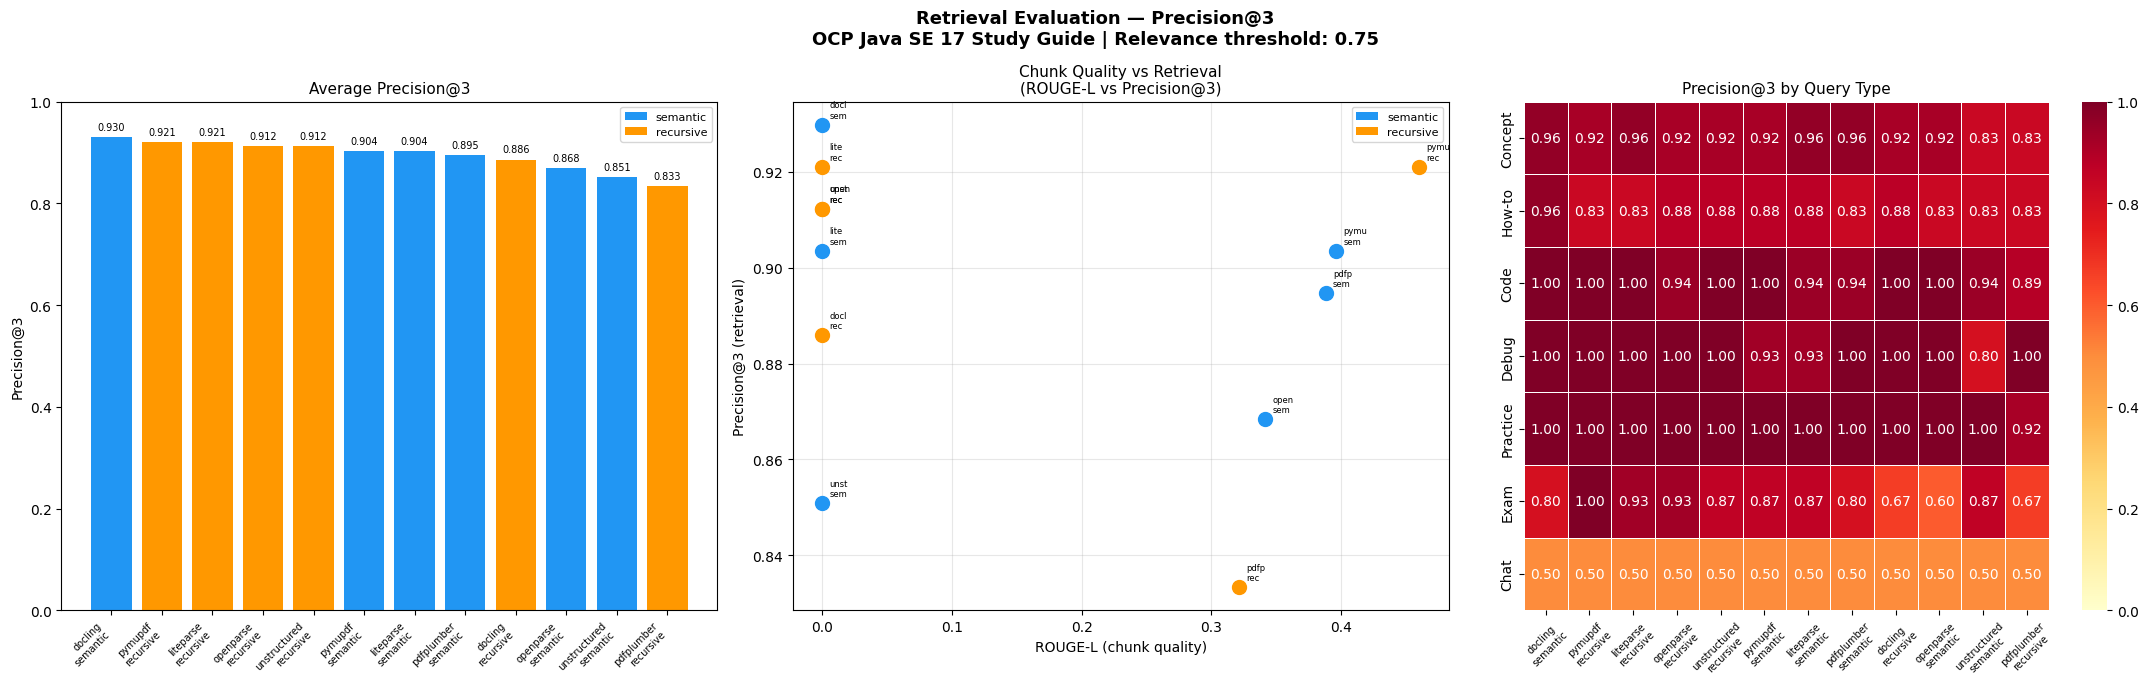

✓ Plot saved to benchmark_results/cell7_retrieval.png

Top 3 by Precision@3:

1. docling+semantic P@3=0.9298 | R@3=0.3376

2. pymupdf+recursive P@3=0.9211 | R@3=0.3875

3. liteparse+recursive P@3=0.9211 | R@3=0.3748

In [25]:
# ============================================================
# CELL 7.4 — Results Table and Visualization
# ============================================================

from rich.table import Table as RichTable

# ---- Aggregate per (parser, chunker) ----
retrieval_summary: dict[tuple[str, str], dict] = {}

for (parser_name, chunker_name) in all_chunks.keys():
    combo_results = [
        r for r in all_retrieval_results
        if r.parser == parser_name and r.chunker == chunker_name
    ]
    if not combo_results:
        continue

    avg_p = sum(r.precision_at_k for r in combo_results) / len(combo_results)
    avg_r = sum(r.recall_at_k for r in combo_results) / len(combo_results)

    type_precision = {}
    for qtype in ["conceptual", "how_to", "code_specific", "debugging",
                  "best_practices", "exam_prep", "conversational"]:
        type_results = [
            r for r in combo_results
            if GOLD_QUERIES[r.query_id]["type"] == qtype
        ]
        type_precision[qtype] = (
            sum(r.precision_at_k for r in type_results) / len(type_results)
            if type_results else 0.0
        )

    retrieval_summary[(parser_name, chunker_name)] = {
        "avg_precision":    avg_p,
        "avg_recall":       avg_r,
        "conceptual":       type_precision["conceptual"],
        "how_to":           type_precision["how_to"],
        "code_specific":    type_precision["code_specific"],
        "debugging":        type_precision["debugging"],
        "best_practices":   type_precision["best_practices"],
        "exam_prep":        type_precision["exam_prep"],
        "conversational":   type_precision["conversational"],
    }

# ---- Print table ----
table = RichTable(
    title=f"Retrieval Evaluation — Precision@{K} and Recall@{K}",
    show_lines=True
)
table.add_column("Parser",        style="cyan", no_wrap=True)
table.add_column("Chunker",       style="white")
table.add_column(f"P@{K}",        justify="right")
table.add_column(f"R@{K}",        justify="right")
table.add_column("Concept",       justify="right")
table.add_column("How-to",        justify="right")
table.add_column("Code",          justify="right")
table.add_column("Debug",         justify="right")
table.add_column("Practice",      justify="right")
table.add_column("Exam",          justify="right")
table.add_column("Chat",          justify="right")

sorted_summary = sorted(
    retrieval_summary.items(),
    key=lambda x: x[1]["avg_precision"],
    reverse=True,
)

for (parser_name, chunker_name), stats in sorted_summary:
    table.add_row(
        parser_name, chunker_name,
        f"{stats['avg_precision']:.3f}",
        f"{stats['avg_recall']:.3f}",
        f"{stats['conceptual']:.3f}",
        f"{stats['how_to']:.3f}",
        f"{stats['code_specific']:.3f}",
        f"{stats['debugging']:.3f}",
        f"{stats['best_practices']:.3f}",
        f"{stats['exam_prep']:.3f}",
        f"{stats['conversational']:.3f}",
    )

console.print(table)

# ---- Visualization ----
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle(
    f"Retrieval Evaluation — Precision@{K}\n"
    f"OCP Java SE 17 Study Guide | Relevance threshold: {RELEVANCE_THRESHOLD}",
    fontsize=13, fontweight="bold"
)

sorted_labels = [f"{p}\n{c}" for (p, c), _ in sorted_summary]
sorted_stats  = [s for _, s in sorted_summary]
colors = ["#2196F3" if c == "semantic" else "#FF9800"
          for (_, c), _ in sorted_summary]

legend_elements = [
    mpatches.Patch(facecolor="#2196F3", label="semantic"),
    mpatches.Patch(facecolor="#FF9800", label="recursive"),
]

# ── Plot 1: Average P@K bar ──────────────────────────────────
ax1 = axes[0]
x = np.arange(len(sorted_labels))
bars = ax1.bar(x, [s["avg_precision"] for s in sorted_stats], color=colors)
ax1.set_title(f"Average Precision@{K}", fontsize=11)
ax1.set_ylabel(f"Precision@{K}")
ax1.set_ylim(0, 1.0)
ax1.set_xticks(x)
ax1.set_xticklabels(sorted_labels, fontsize=7, rotation=45, ha="right")
for bar, stat in zip(bars, sorted_stats):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{stat['avg_precision']:.3f}",
        ha="center", va="bottom", fontsize=7
    )
ax1.legend(handles=legend_elements, fontsize=8)

# ── Plot 2: P@K vs ROUGE-L scatter ──────────────────────────
ax2 = axes[1]
for (parser_name, chunker_name), stats in sorted_summary:
    rouge = quality_reports[(parser_name, chunker_name)].avg_rouge_l
    precision = stats["avg_precision"]
    color = "#2196F3" if chunker_name == "semantic" else "#FF9800"
    ax2.scatter(rouge, precision, color=color, s=100, zorder=5)
    ax2.annotate(
        f"{parser_name[:4]}\n{chunker_name[:3]}",
        (rouge, precision),
        textcoords="offset points",
        xytext=(5, 5), fontsize=6,
    )
ax2.set_title("Chunk Quality vs Retrieval\n(ROUGE-L vs Precision@3)", fontsize=11)
ax2.set_xlabel("ROUGE-L (chunk quality)")
ax2.set_ylabel(f"Precision@{K} (retrieval)")
ax2.legend(handles=legend_elements, fontsize=8)
ax2.grid(True, alpha=0.3)

# ── Plot 3: P@K by query type heatmap ───────────────────────
ax3 = axes[2]
qtypes = ["conceptual", "how_to", "code_specific", "debugging",
          "best_practices", "exam_prep", "conversational"]
type_labels = ["Concept", "How-to", "Code", "Debug",
               "Practice", "Exam", "Chat"]

heatmap_data = np.array([
    [s[qt] for qt in qtypes]
    for s in sorted_stats
]).T

sns.heatmap(
    heatmap_data,
    ax=ax3,
    annot=True, fmt=".2f",
    xticklabels=sorted_labels,
    yticklabels=type_labels,
    cmap="YlOrRd",
    vmin=0, vmax=1,
    linewidths=0.5,
)
ax3.set_title(f"Precision@{K} by Query Type", fontsize=11)
ax3.tick_params(axis="x", labelsize=7, rotation=45)

plt.tight_layout()
plot_path = RESULTS_DIR / "cell7_retrieval.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
console.print(f"\n[green]✓ Plot saved to {plot_path}[/green]")

# ── Top 3 summary ────────────────────────────────────────────
console.print(f"\n[bold]Top 3 by Precision@{K}:[/bold]")
for i, ((p, c), s) in enumerate(sorted_summary[:3]):
    console.print(
        f"  {i+1}. [cyan]{p}[/cyan]+[white]{c}[/white] "
        f"P@3={s['avg_precision']:.4f} | R@3={s['avg_recall']:.4f}"
    )

In [ ]:
# ============================================================
# CELL 7.5 — End-to-End Generation Quality Evaluation
#
# For a subset of queries:
#   1. Retrieve top-3 chunks from each (parser, chunker) combo
#   2. Stuff into a RAG prompt, generate answer with Ollama
#   3. Use LLM-as-judge to score faithfulness + relevance
#
# Uses qwen2.5-coder:7b (same as CodeMentor production) for both
# generation and judging. Note: same-model judging has bias —
# we acknowledge this in the blog post as a known limitation.
#
# Memory: free the embedding model before loading Ollama to avoid
# OOM on a 6GB GPU.
# ============================================================

import gc
import json
import ollama
from tqdm import tqdm

# ---- Free embedding model VRAM before Ollama loads ----
console.print("[bold]Freeing VRAM before generation...[/bold]")
try:
    import torch
    del embedding_model
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    gc.collect()
    console.print("  ✓ VRAM cleared")
except Exception as e:
    console.print(f"  [yellow]Warning: {e}[/yellow]")

OLLAMA_MODEL = "qwen2.5-coder:7b"
OLLAMA_HOST = "http://localhost:11434"

# Test Ollama is reachable
try:
    ollama_client = ollama.Client(host=OLLAMA_HOST)
    models = ollama_client.list()
    console.print(f"  ✓ Ollama ready, model: {OLLAMA_MODEL}")
except Exception as e:
    console.print(f"  [red]✗ Ollama not available: {e}[/red]")
    raise

# ---- Select representative query subset ----
EVAL_QUERY_IDS = [
    "q01",  # conceptual: lambda expression
    "q05",  # conceptual: functional interface
    "q09",  # how_to: loop through arraylist
    "q11",  # how_to: implement interface
    "q17",  # code_specific: lambda example
    "q19",  # code_specific: constructor example
    "q23",  # debugging: NullPointerException
    "q28",  # best_practices: interface vs abstract
    "q33",  # exam_prep: access modifiers
    "q36",  # exam_prep: == vs equals
]
eval_queries = [q for q in GOLD_QUERIES if q["id"] in EVAL_QUERY_IDS]
console.print(f"  Evaluating {len(eval_queries)} queries across "
              f"{len(all_chunks)} combinations")
console.print(f"  Total LLM calls: {len(eval_queries) * len(all_chunks) * 2}")


# ---- Prompt templates ----

RAG_SYSTEM_PROMPT = """You are a Java programming tutor. Answer the user's question \
based on the provided context from a Java study guide. If the context doesn't \
contain enough information, say so. Keep your answer concise and include code \
examples when relevant."""

def build_rag_prompt(query: str, chunks: list[str]) -> str:
    context = "\n\n---\n\n".join(chunks)
    return f"""Context from Java study guide:

{context}

Student question: {query}

Answer:"""

JUDGE_SYSTEM_PROMPT = """You are an impartial evaluator of RAG system answers. \
You will be given a question, the context chunks provided, and a generated \
answer. Score the answer on two dimensions:

1. FAITHFULNESS (0-5): Is every claim in the answer supported by the context?
   - 5: Every statement directly backed by context
   - 3: Mostly backed but some inferences
   - 0: Answer contradicts or ignores context

2. RELEVANCE (0-5): Does the answer actually address the question?
   - 5: Directly answers with right scope and detail
   - 3: Partial answer or slightly off-topic
   - 0: Does not address the question

Respond ONLY with a JSON object in this exact format, no other text:
{"faithfulness": <int>, "relevance": <int>, "reasoning": "<one short sentence>"}"""

def build_judge_prompt(query: str, context_chunks: list[str], answer: str) -> str:
    context = "\n\n---\n\n".join(context_chunks)
    return f"""Question: {query}

Context provided:
{context}

Generated answer:
{answer}

Score the answer and return ONLY JSON:"""


def generate(system: str, user: str) -> str:
    """Single Ollama generation call."""
    response = ollama_client.chat(
        model=OLLAMA_MODEL,
        messages=[
            {"role": "system", "content": system},
            {"role": "user", "content": user},
        ],
        options={
            "temperature": 0.1,  # low temp for consistent judging
            "num_ctx": 8192,
        },
    )
    return response["message"]["content"]


def parse_judge_response(raw: str) -> dict:
    """Extract JSON from judge response, handle various formats."""
    raw = raw.strip()
    # Strip markdown code fences if present
    if raw.startswith("```"):
        raw = raw.split("```")[1]
        if raw.startswith("json"):
            raw = raw[4:]
    try:
        parsed = json.loads(raw.strip())
        return {
            "faithfulness": int(parsed.get("faithfulness", 0)),
            "relevance":    int(parsed.get("relevance", 0)),
            "reasoning":    parsed.get("reasoning", ""),
        }
    except (json.JSONDecodeError, ValueError, KeyError):
        return {"faithfulness": 0, "relevance": 0, "reasoning": "parse_error"}


# ---- Run evaluation ----

generation_results = []

total_iterations = len(all_chunks) * len(eval_queries)
progress = tqdm(total=total_iterations, desc="Generating + judging")

for (parser_name, chunker_name), chunks in all_chunks.items():
    if not chunks:
        continue

    collection_name = f"{QDRANT_COLLECTION_PREFIX}{parser_name}_{chunker_name}"
    chunk_id_to_text = {c.chunk_id: c.text for c in chunks}

    for query in eval_queries:
        progress.set_description(
            f"{parser_name[:4]}+{chunker_name[:3]} | {query['id']}"
        )

        # ---- Retrieve top-3 chunks ----
        q_emb_cached = query_embeddings[query["id"]]
        results = qdrant.query_points(
            collection_name=collection_name,
            query=q_emb_cached.tolist(),
            limit=3,
            with_payload=True,
        ).points
        retrieved_texts = [r.payload["text"] for r in results]

        # ---- Generate answer ----
        try:
            answer = generate(
                RAG_SYSTEM_PROMPT,
                build_rag_prompt(query["query"], retrieved_texts),
            )
        except Exception as e:
            answer = f"[generation error: {e}]"

        # ---- Judge answer ----
        try:
            judge_raw = generate(
                JUDGE_SYSTEM_PROMPT,
                build_judge_prompt(query["query"], retrieved_texts, answer),
            )
            scores = parse_judge_response(judge_raw)
        except Exception as e:
            scores = {"faithfulness": 0, "relevance": 0, "reasoning": f"judge_error: {e}"}

        generation_results.append({
            "parser":       parser_name,
            "chunker":      chunker_name,
            "query_id":     query["id"],
            "query_type":   query["type"],
            "query":        query["query"],
            "answer":       answer,
            "faithfulness": scores["faithfulness"],
            "relevance":    scores["relevance"],
            "reasoning":    scores["reasoning"],
        })
        progress.update(1)

progress.close()

# Save raw results
import json as _json
with open(RESULTS_DIR / "generation_eval.json", "w") as f:
    _json.dump(generation_results, f, indent=2)

console.print(f"\n[green]✓ {len(generation_results)} generation evaluations complete[/green]")
console.print(f"[green]✓ Saved to {RESULTS_DIR / 'generation_eval.json'}[/green]")

ModuleNotFoundError: No module named 'ollama'